# GRA: magnetic steering

project = ```GRA```, host = ```mach```, device = ```cuda:2```

## Goals:

`magnetic steering` + test on `rosenbrock` simulation

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D


def _cov_ellipse(mean_xy, cov, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = np.clip(vals[order], 0.0, None)
    vecs = vecs[:, order]

    width, height = 2.0 * n_std * np.sqrt(vals + 1e-20)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    return Ellipse(xy=mean_xy, width=width, height=height, angle=angle, **kwargs)


def plot_rosenbrock_trajectories(
        results,
        a: float = 1.0,
        *,
        every=10,
        contour=True,
        levels=40,
        k_tail=200,
        n_std=5.0,
        cmap="cividis",
        ellipse_color='C6',
        title="Rosenbrock trajectories (color = time)",
        zoom=None,  # None | float | ("tail", margin)
    ):
    
    rosenbrock_fn = get_rosenbrock_fun(a)
    x_opt, y_opt = float(a), float(a) ** 2

    names = list(results.keys())
    m = len(names)
    ncols = min(2, m)
    nrows = int(np.ceil(m / ncols))

    # ----- bounds (with optional zoom) -----
    if zoom is None:
        all_xy = np.concatenate([results[k] for k in names], axis=0)
        xmin, ymin = all_xy.min(axis=0)
        xmax, ymax = all_xy.max(axis=0)
        dx, dy = (xmax - xmin), (ymax - ymin)
        xmin -= 0.20 * dx
        xmax += 0.20 * dx
        ymin -= 0.20 * dy
        ymax += 0.20 * dy

    elif isinstance(zoom, (int, float)):
        z = float(zoom)
        xmin, xmax = x_opt - z, x_opt + z
        ymin, ymax = y_opt - z, y_opt + z

    else:
        mode, margin = zoom
        if mode != "tail":
            raise ValueError("zoom must be None, a float, or ('tail', margin)")
        margin = float(margin)

        tails = []
        for name in names:
            path = results[name]
            k = int(max(1, min(k_tail, len(path))))
            tails.append(path[-k:, :])
        tail_xy = np.concatenate(tails, axis=0)

        xmin, ymin = tail_xy.min(axis=0)
        xmax, ymax = tail_xy.max(axis=0)
        dx, dy = (xmax - xmin), (ymax - ymin)
        xmin -= margin * dx
        xmax += margin * dx
        ymin -= margin * dy
        ymax += margin * dy
    # --------------------------------------

    if contour:
        xs = np.linspace(xmin, xmax, 400)
        ys = np.linspace(ymin, ymax, 400)
        X, Y = np.meshgrid(xs, ys)
        Z = rosenbrock_fn(X, Y)
        Z = np.log10(Z + 1e-12)

    fig, axes = create_figure(
        nrows, ncols,
        figsize=(4 * ncols, 4 * nrows),
        sharex="all", sharey="all",
    )
    fig.suptitle(title)

    last_scatter = None

    for i, name in enumerate(names):
        ax = axes[i // ncols][i % ncols]
        path = results[name]
        T = path.shape[0]
        idx = np.arange(0, T, every)

        if contour:
            ax.contour(X, Y, Z, levels=levels, colors="0.75", linewidths=0.8, zorder=0)

        ax.plot(path[:, 0], path[:, 1], lw=0.8, color="0.2", alpha=0.35, zorder=1)

        last_scatter = ax.scatter(
            path[idx, 0], path[idx, 1],
            c=idx, s=12, cmap=cmap, linewidths=0, zorder=2
        )

        # start: empty black circle
        ax.scatter(
            path[0, 0], path[0, 1],
            s=80, marker="o",
            facecolors="none", edgecolors='k',
            linewidths=1.5, zorder=4,
        )

        # final: empty blue circle
        ax.scatter(
            path[-1, 0], path[-1, 1],
            s=300, marker="o",
            facecolors="none", edgecolors='blue',
            linewidths=1.5, zorder=4,
            alpha=0.4,
        )

        # tail mean + fluctuation ellipse
        k = int(max(1, min(k_tail, T)))
        tail = path[-k:, :]
        mean_xy = tail.mean(axis=0)
        ax.scatter(mean_xy[0], mean_xy[1], s=90, marker="x", color="red", linewidths=2.0, zorder=6)

        if k >= 2:
            cov = np.cov(tail.T, bias=False)
            ax.add_patch(_cov_ellipse(
                mean_xy, cov, n_std=n_std,
                facecolor="none", edgecolor=ellipse_color, linestyle="--", linewidth=1.2, zorder=3
            ))

        # optimum: black star
        ax.scatter(x_opt, y_opt, s=140, marker="*", color="k", zorder=6)

        ax.set_title(name)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        if (i % ncols) == 0:
            ax.set_ylabel("y")
        if (i // ncols) == (nrows - 1):
            ax.set_xlabel("x")

    for j in range(m, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.subplots_adjust(right=0.88, bottom=0.14, top=0.92)

    if last_scatter is not None:
        cax = fig.add_axes([1.04, 0.20, 0.02, 0.65])
        cbar = fig.colorbar(last_scatter, cax=cax)
        cbar.set_label("step")

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="none",
               markeredgecolor="k", markeredgewidth=1.5, markersize=8, label="start"),
        Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="none",
               markeredgecolor="blue", markeredgewidth=1.5, markersize=10, alpha=0.7, label="final"),
        Line2D([0], [0], marker="x", linestyle="None", color="red",
               markersize=8, markeredgewidth=2.0, label=f"mean(last {int(k_tail)})"),
        Line2D([0], [0], marker="*", linestyle="None", color="k",
               markersize=10, label=f"optimum ({a}, {a**2})"),
        Line2D([0], [0], linestyle="--", color=ellipse_color, linewidth=1.2,
               label=f"fluctuation ({n_std}σ ellipse)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04), ncol=5, frameon=False
    )

    plt.show()

In [3]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

In [4]:
from optimzers import *
from test.test import *

In [5]:
def get_rosenbrock_fun(a: float = 1.0):
    def _rosenbrock(x, y):
        return (a - x)**2 + 100 * (y - x**2)**2

    return _rosenbrock


def make_opt(opt_class, opt_kws: dict = None, steer_kws: dict = None):
    def _fn(params):
        opt = opt_class(params, **opt_kws)
        if steer_kws is not None:
            opt = MaxwellSteeringOptimizer(
                base_optimizer=opt, **steer_kws)
        return opt
    return _fn


def run_experiment(opt_fn, a=1.0, init=None, steps=4_000):
    # get function
    rosenbrock = get_rosenbrock_fun(a)
    
    # start at a tricky point
    if init is None:
        init = [-1.5, -1.0]
    params = torch.tensor(init, requires_grad=True)
    
    opt = opt_fn([params])

    path = []
    losses = []
    
    for _ in range(steps):
        opt.zero_grad()
        loss = rosenbrock(params[0], params[1])
        loss.backward()
        opt.step()
        
        path.append(params.detach().numpy().copy())
        losses.append(loss.item())
        
    return np.array(path), losses

## Adam

`a = 1`

In [30]:
%%time


opt_kws = dict(lr=1e-2)
expt_kws = dict(a=1.0, steps=4_000)


# Adam
opt_fn = make_opt(torch.optim.AdamW, opt_kws)
path_adam, loss_adam = run_experiment(opt_fn, **expt_kws)

# # Adam + Steer (0.1)
# opt_fn = make_opt(
#     opt_class=torch.optim.AdamW,
#     opt_kws=opt_kws,
#     steer_kws={'steering_strength': 0.2},
# )
# path_adam_1, loss_adam_1 = run_experiment(opt_fn, **expt_kws)

# # Adam + Steer (0.5)
# opt_fn = make_opt(
#     opt_class=torch.optim.AdamW,
#     opt_kws=opt_kws,
#     steer_kws={'steering_strength': 0.5},
# )
# path_adam_5, loss_adam_5 = run_experiment(opt_fn, **expt_kws)

# Adam + Steer (0.9)
opt_fn = make_opt(
    opt_class=torch.optim.AdamW,
    opt_kws=opt_kws,
    steer_kws={'steering_strength': 100.0},
)
path_adam_9, loss_adam_9 = run_experiment(opt_fn, **expt_kws)

CPU times: user 4.18 s, sys: 1.99 ms, total: 4.18 s
Wall time: 4.18 s


In [31]:
k = 10

print(f"\nFinal Loss Adam: {smooth_1d(loss_adam, k=k)[-1]:.6f}")
# print(f"Final Loss Adam (w/ steer = 0.1): {smooth_1d(loss_adam_1, k=k)[-1]:.6f}")
# print(f"Final Loss Adam (w/ steer = 0.5): {smooth_1d(loss_adam_5, k=k)[-1]:.6f}")
print(f"Final Loss Adam (w/ steer = 0.9): {smooth_1d(loss_adam_9, k=k)[-1]:.6f}")

Final Loss Adam: 0.323616

Final Loss Adam (w/ steer = 0.9): 0.890046

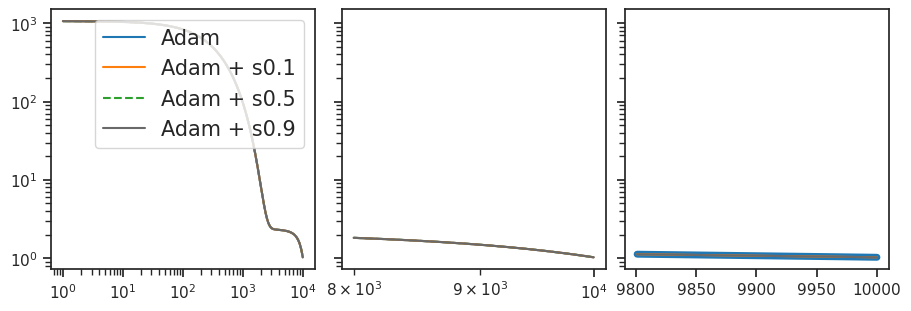

In [8]:
invls = [slice(None), slice(-2000, None), slice(-200, None)]

n = len(loss_adam)
x = np.arange(1, n + 1)

fig, axes = create_figure(1, 3, (9, 3), sharey="row")
for i, (ax, intvl) in enumerate(zip(axes, invls)):
    if i == len(invls) - 1:
        ax.semilogy(x[intvl], loss_adam[intvl], label="Adam", lw=5)
        ax.semilogy(x[intvl], loss_adam_1[intvl], label="Adam + s0.1")
        ax.semilogy(x[intvl], loss_adam_5[intvl], label="Adam + s0.5", ls="--", zorder=-1)
        ax.semilogy(x[intvl], loss_adam_9[intvl], label="Adam + s0.9", color="dimgrey")
    else:
        ax.loglog(x[intvl], loss_adam[intvl], label="Adam")
        ax.loglog(x[intvl], loss_adam_1[intvl], label="Adam + s0.1")
        ax.loglog(x[intvl], loss_adam_5[intvl], label="Adam + s0.5", ls="--", zorder=-1)
        ax.loglog(x[intvl], loss_adam_9[intvl], label="Adam + s0.9", color="dimgrey")

axes[0].legend(fontsize=15)
plt.show()

In [ ]:
results_to_plot = {
    "Adam": path_adam,
    "Lion": path_lion,
    "Relativistic Lion": path_rel,
    "General Relativistic Lion": path_gr,
}

In [ ]:
plot_rosenbrock_trajectories(results_to_plot, a=a, every=100, contour=True, n_std=200)

In [ ]:
plot_rosenbrock_trajectories(results_to_plot, a=a, every=50, contour=True, zoom=True, n_std=100)

## rosenbrock w/o magnetic steering

`a = 1`

In [5]:
%%time


lr = 1e-3
a = 1.0

path_adam, loss_adam = run_experiment(
    torch.optim.Adam, {'lr': lr}, a=a)

path_lion, loss_lion = run_experiment(
    Lion, {'lr': lr}, a=a)

path_rel, loss_rel = run_experiment(
    RelativisticLion, {'lr': lr, 'mass': 100.0}, a=a)

path_gr, loss_gr = run_experiment(
    GeneralRelativisticLion, {'lr': lr, 'mass': 100.0}, a=a)


CPU times: user 4.45 s, sys: 55.3 ms, total: 4.51 s
Wall time: 4.52 s


In [6]:
k = 10

print(f"\nFinal Loss Adam: {smooth_1d(loss_adam, k=k)[-1]:.6f}")
print(f"Final Loss Lion: {smooth_1d(loss_lion, k=k)[-1]:.6f}")
print(f"Final Loss Relativistic: {smooth_1d(loss_rel, k=k)[-1]:.6f}")
print(f"Final Loss Geneneral Relativistic: {smooth_1d(loss_gr, k=k)[-1]:.6f}\n")

Final Loss Adam: 1.382727

Final Loss Lion: 0.000269

Final Loss Relativistic: 0.000208

Final Loss Geneneral Relativistic: 0.000000

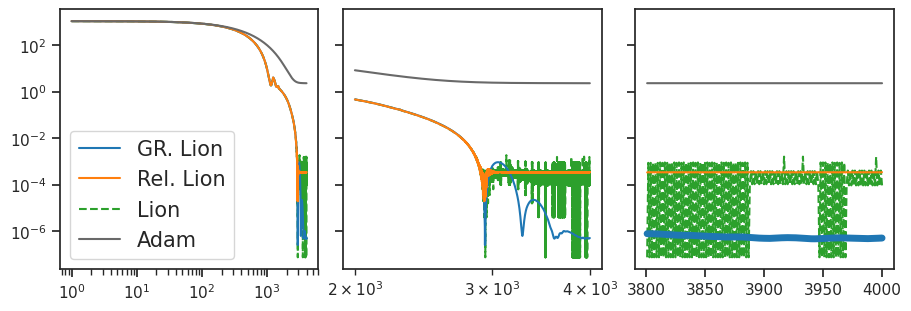

In [7]:
invls = [slice(None), slice(-2000, None), slice(-200, None)]

n = len(loss_gr)
x = np.arange(1, n + 1)

fig, axes = create_figure(1, 3, (9, 3), sharey="row")
for i, (ax, intvl) in enumerate(zip(axes, invls)):
    if i == len(invls) - 1:
        ax.semilogy(x[intvl], loss_gr[intvl], label="GR. Lion", lw=5)
        ax.semilogy(x[intvl], loss_rel[intvl], label="Rel. Lion")
        ax.semilogy(x[intvl], loss_lion[intvl], label="Lion", ls="--", zorder=-1)
        ax.semilogy(x[intvl], loss_adam[intvl], label="Adam", color="dimgrey")
    else:
        ax.loglog(x[intvl], loss_gr[intvl], label="GR. Lion")
        ax.loglog(x[intvl], loss_rel[intvl], label="Rel. Lion")
        ax.loglog(x[intvl], loss_lion[intvl], label="Lion", ls="--", zorder=-1)
        ax.loglog(x[intvl], loss_adam[intvl], label="Adam", color="dimgrey")

axes[0].legend(fontsize=15)
plt.show()

In [8]:
results_to_plot = {
    "Adam": path_adam,
    "Lion": path_lion,
    "Relativistic Lion": path_rel,
    "General Relativistic Lion": path_gr,
}

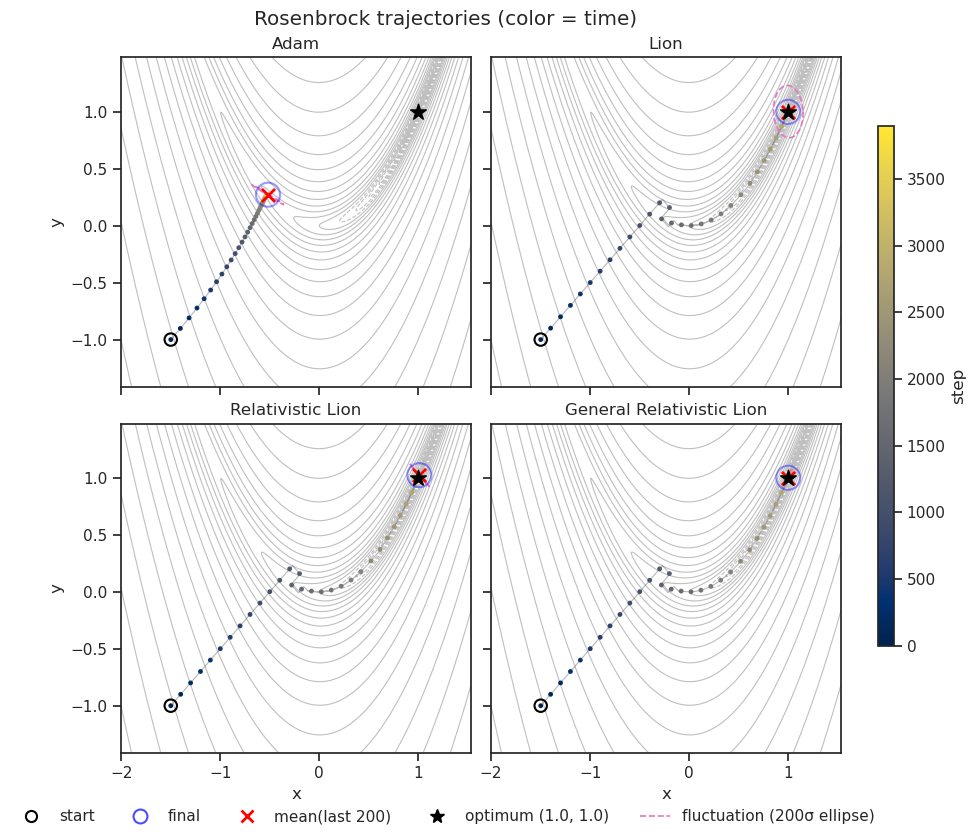

In [9]:
plot_rosenbrock_trajectories(results_to_plot, a=a, every=100, contour=True, n_std=200)

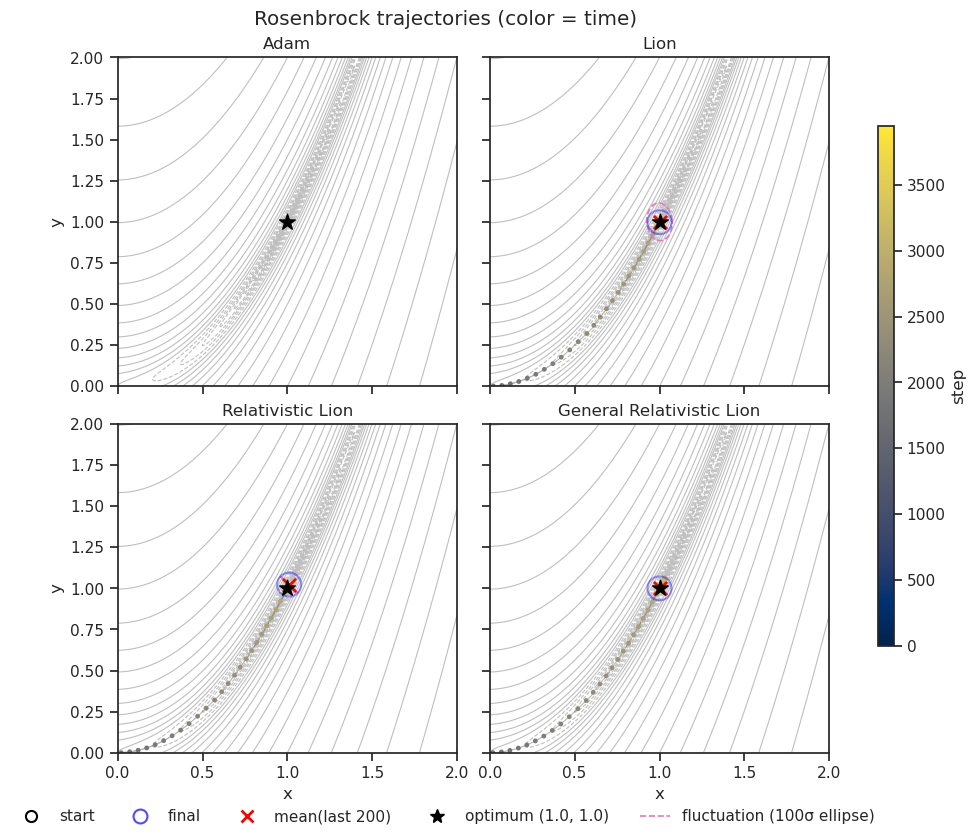

In [10]:
plot_rosenbrock_trajectories(results_to_plot, a=a, every=50, contour=True, zoom=True, n_std=100)

In [36]:
import torch
from torch.optim import Optimizer

class RelativisticMemoryOptimizer(Optimizer):
    def __init__(self, base_optimizer, memory_timescale=0.01, coupling_strength=10.0, gamma_scaling=100.0):
        """
        Args:
            gamma_scaling: Controls how easily 'speed' breaks the memory bond.
                           Higher = easier to learn new tasks (more plastic).
        """
        self.base_optimizer = base_optimizer
        self.tau = memory_timescale
        self.lamb = coupling_strength
        self.gamma_scale = gamma_scaling 
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        self._update_memory_and_force()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _update_memory_and_force(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                if p not in self.state: continue
                
                state = self.state[p]
                if len(state) == 0: continue
                
                # Init Memory
                if 'phi_field' not in state:
                    state['phi_field'] = p.detach().clone()
                phi = state['phi_field']
                
                # Get Velocity (Adam exp_avg or SGD momentum)
                velocity = None
                if 'exp_avg' in state: 
                    velocity = state['exp_avg']
                elif 'momentum_buffer' in state: 
                    velocity = state['momentum_buffer']
                
                # --- The Relativistic Correction ---
                # Calculate Lorentz Factor approximation: gamma ~ 1 + v^2/c^2
                # If velocity is high, gamma is high, and Force is LOW.
                
                if velocity is not None:
                    v_sq = torch.sum(velocity * velocity) # Scalar speed of this parameter tensor
                    # Normalizing by number of params to keep scale consistent
                    v_sq = v_sq / p.numel() 
                    
                    gamma_inv = 1.0 / (1.0 + self.gamma_scale * v_sq)
                else:
                    gamma_inv = 1.0

                # Force = (lambda / gamma) * (theta - phi)
                # High speed -> gamma_inv small -> Weak Force -> High Plasticity
                # Low speed -> gamma_inv ~ 1 -> Strong Force -> High Stability
                restoring_force = self.lamb * gamma_inv * (p - phi)
                p.grad.add_(restoring_force)
                
                # Update Memory (also gated by speed? Optional, but keep simple for now)
                phi.add_(p - phi, alpha=self.tau)

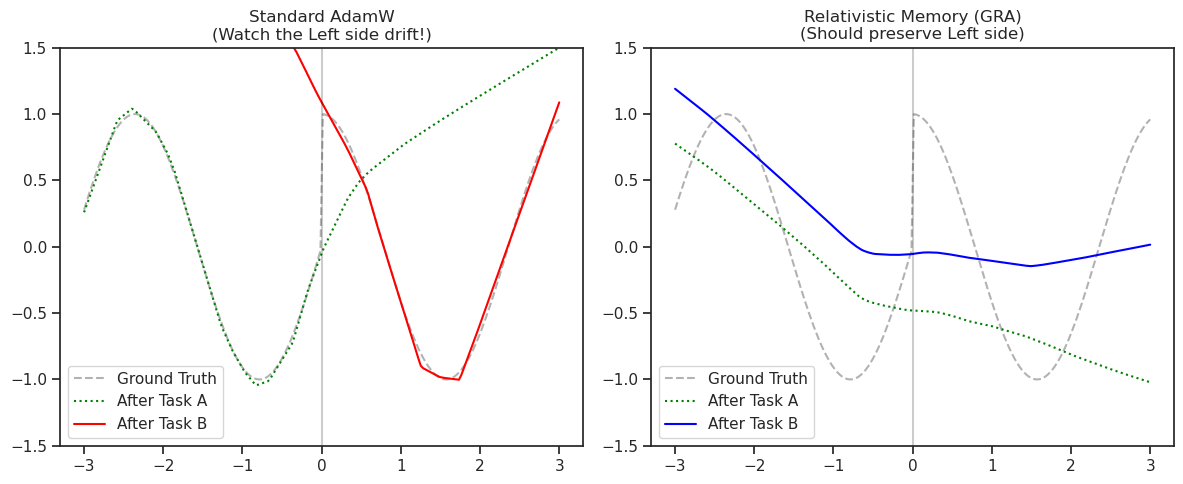

In [37]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup: Sequential Learning Task
# ==========================================
def generate_data(task_id, n=100):
    if task_id == 'A':
        # Task A: Learn Sine wave on [-3, 0]
        x = torch.linspace(-3, 0, n).unsqueeze(1)
        y = torch.sin(x * 2) + 0.1 * torch.randn_like(x)
    else:
        # Task B: Learn Cosine wave on [0, 3]
        x = torch.linspace(0, 3, n).unsqueeze(1)
        y = torch.cos(x * 2) + 0.1 * torch.randn_like(x)
    return x, y

# Simple MLP
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

# ==========================================
# 2. Experiment Runner
# ==========================================
def run_forgetting_test(use_memory=False):
    # Reset Model
    for layer in model:
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()
            
    # Optimizer Selection
    base_opt = torch.optim.AdamW(model.parameters(), lr=0.01)
    
    if use_memory:
        # Enable Relativistic Memory (Scalar Field)
        # tau=0.01 (Slow update), lambda=10.0 (Strong retention)
        opt = RelativisticMemoryOptimizer(base_opt, memory_timescale=0.01, coupling_strength=10.0)
        label = "Relativistic Memory (GRA)"
    else:
        opt = base_opt
        label = "Standard AdamW"

    criterion = nn.MSELoss()
    
    # --- Phase 1: Train on Task A ---
    x_a, y_a = generate_data('A')
    for step in range(500):
        opt.zero_grad()
        pred = model(x_a)
        loss = criterion(pred, y_a)
        loss.backward()
        opt.step()
        
    # Snapshot predictions after Task A (The "Gold Standard")
    with torch.no_grad():
        full_range = torch.linspace(-3, 3, 200).unsqueeze(1)
        after_a_pred = model(full_range)
        
    # --- Phase 2: Train on Task B (Forget A?) ---
    x_b, y_b = generate_data('B')
    for step in range(500):
        opt.zero_grad()
        pred = model(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        opt.step()
        
    # Snapshot predictions after Task B
    with torch.no_grad():
        after_b_pred = model(full_range)
        
    return full_range, after_a_pred, after_b_pred, label

# ==========================================
# 3. Visualize
# ==========================================
plt.figure(figsize=(12, 5))

# Run Standard
x, a_std, b_std, label_std = run_forgetting_test(use_memory=False)

# Run Memory
x, a_mem, b_mem, label_mem = run_forgetting_test(use_memory=True)

# Ground Truth
x_np = x.numpy().flatten()
y_true = np.concatenate([np.sin(x_np[x_np<0]*2), np.cos(x_np[x_np>=0]*2)])

# Plot 1: Standard Adam
plt.subplot(1, 2, 1)
plt.plot(x, y_true, 'k--', alpha=0.3, label='Ground Truth')
plt.plot(x, a_std, 'g:', label='After Task A')
plt.plot(x, b_std, 'r-', label='After Task B')
plt.title(f"{label_std}\n(Watch the Left side drift!)")
plt.legend()
plt.ylim(-1.5, 1.5)
plt.axvline(0, color='k', alpha=0.2)

# Plot 2: Relativistic Memory
plt.subplot(1, 2, 2)
plt.plot(x, y_true, 'k--', alpha=0.3, label='Ground Truth')
plt.plot(x, a_mem, 'g:', label='After Task A')
plt.plot(x, b_mem, 'b-', label='After Task B')
plt.title(f"{label_mem}\n(Should preserve Left side)")
plt.legend()
plt.ylim(-1.5, 1.5)
plt.axvline(0, color='k', alpha=0.2)

plt.tight_layout()
plt.show()

In [43]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. The Robust Relativistic Optimizer
#    (Included here to ensure we use the Speed-Gated version)
# ==========================================
class RelativisticMemoryOptimizer(torch.optim.Optimizer):
    def __init__(self, base_optimizer, memory_timescale=0.01, coupling_strength=10.0, gamma_scaling=1000.0):
        self.base_optimizer = base_optimizer
        self.tau = memory_timescale
        self.lamb = coupling_strength
        self.gamma_scale = gamma_scaling 
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        self._update_memory_and_force()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _update_memory_and_force(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or p not in self.state: continue
                state = self.state[p]
                if len(state) == 0: continue
                
                # Init Memory
                if 'phi_field' not in state:
                    state['phi_field'] = p.detach().clone()
                phi = state['phi_field']
                
                # Calculate Velocity (Squared Speed)
                velocity = None
                if 'exp_avg' in state: velocity = state['exp_avg']
                elif 'momentum_buffer' in state: velocity = state['momentum_buffer']
                
                gamma_inv = 1.0
                if velocity is not None:
                    # Metric: Average squared velocity per parameter element
                    v_sq = torch.mean(velocity**2).item()
                    
                    # Gamma Factor: Suppresses force when moving fast
                    # If v_sq is 1e-4 and gamma_scale is 1e4, gamma ~ 2.
                    gamma_inv = 1.0 / (1.0 + self.gamma_scale * v_sq)

                # Apply Relativistic Force
                # F = - grad(V) = lambda * gamma_inv * (theta - phi)
                restoring_force = self.lamb * gamma_inv * (p - phi)
                p.grad.add_(restoring_force)
                
                # Update Memory (Dissipative)
                phi.add_(p - phi, alpha=self.tau)

# ==========================================
# 2. Evaluation Utilities
# ==========================================
def get_loss(model, x, y):
    criterion = nn.MSELoss()
    with torch.no_grad():
        pred = model(x)
        return criterion(pred, y).item()

def generate_tasks(n=150):
    # Task A: Sine on [-3, 0]
    xa = torch.linspace(-3, 0, n).unsqueeze(1)
    ya = torch.sin(xa * 2)
    # Task B: Cosine on [0, 3]
    xb = torch.linspace(0, 3, n).unsqueeze(1)
    yb = torch.cos(xb * 2)
    return (xa, ya), (xb, yb)

# ==========================================
# 3. Systematic Experiment Runner
# ==========================================
def run_quantified_test(opt_config, steps_per_task=1000):
    # 1. Setup Model
    model = nn.Sequential(
        nn.Linear(1, 128), nn.Tanh(),
        nn.Linear(128, 128), nn.Tanh(),
        nn.Linear(128, 1)
    )
    
    # 2. Setup Optimizer
    base_lr = 0.005
    base_opt = torch.optim.AdamW(model.parameters(), lr=base_lr)
    
    if opt_config['type'] == 'GRA':
        opt = RelativisticMemoryOptimizer(
            base_opt, 
            memory_timescale=0.01,           # Slow memory update
            coupling_strength=opt_config['lambda'], 
            gamma_scaling=opt_config['gamma']
        )
    else:
        opt = base_opt

    # 3. Data
    (xa, ya), (xb, yb) = generate_tasks()
    criterion = nn.MSELoss()

    # --- PHASE 1: Train Task A ---
    for _ in range(steps_per_task):
        opt.zero_grad()
        loss = criterion(model(xa), ya)
        loss.backward()
        opt.step()
        
    # Metric: Performance on A immediately after A
    loss_a_after_a = get_loss(model, xa, ya)

    # --- PHASE 2: Train Task B ---
    for _ in range(steps_per_task):
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        
    # Metrics Final
    loss_a_final = get_loss(model, xa, ya)
    loss_b_final = get_loss(model, xb, yb)
    
    # --- Quantify ---
    # Forgetting: How much did A worsen?
    forgetting = loss_a_final - loss_a_after_a
    
    # Plasticity (Proxy): How well did we learn B? (Lower is better)
    plasticity_loss = loss_b_final
    
    return {
        "Config": opt_config['label'],
        "Forgetting (A)": forgetting,
        "Plasticity Loss (B)": plasticity_loss,
        "Total MSE": (loss_a_final + loss_b_final) / 2
    }

# ==========================================
# 4. Run the Sweep
# ==========================================
configs = [
    {'type': 'Standard', 'label': 'AdamW (Baseline)'},
    
    # Static Memory (Gamma=0 effectively)
    {'type': 'GRA', 'lambda': 10.0, 'gamma': 0.0, 'label': 'GRA (Static)'},
    
    # Relativistic: Try increasing Gamma Scaling to fix plasticity
    {'type': 'GRA', 'lambda': 10.0, 'gamma': 1.0, 'label': 'GRA (Gamma=1)'},
    {'type': 'GRA', 'lambda': 10.0, 'gamma': 10.0, 'label': 'GRA (Gamma=10)'},
    {'type': 'GRA', 'lambda': 10.0, 'gamma': 100.0, 'label': 'GRA (Gamma=100)'},
]

results = []
print(f"{'Configuration':<25} | {'Forgetting':<12} | {'Plasticity (B)':<15} | {'Total MSE':<10}")
print("-" * 70)

for conf in configs:
    # Run multiple seeds for robustness? Let's just run 1 for speed here.
    res = run_quantified_test(conf, steps_per_task=1500) # Increased steps
    results.append(res)
    
    print(f"{res['Config']:<25} | {res['Forgetting (A)']:<12.4f} | {res['Plasticity Loss (B)']:<15.4f} | {res['Total MSE']:<10.4f}")

# Convert to DataFrame for easier reading if needed
df = pd.DataFrame(results)

Configuration             | Forgetting   | Plasticity (B)  | Total MSE

----------------------------------------------------------------------

AdamW (Baseline)          | 2.0004       | 0.0004          | 1.0004

GRA (Static)              | 0.9339       | 0.2954          | 0.6867

GRA (Gamma=1)             | 1.2091       | 0.3239          | 0.8514

GRA (Gamma=10)            | 1.3434       | 0.3064          | 0.9041

GRA (Gamma=100)           | 1.4150       | 0.2831          | 0.9175

In [45]:
df

,Config,Forgetting (A),Plasticity Loss (B),Total MSE
0,AdamW (Baseline),2.000376,0.000396,1.000389
1,GRA (Static),0.933924,0.295370,0.686683
2,GRA (Gamma=1),1.209130,0.323895,0.851430
3,GRA (Gamma=10),1.343440,0.306352,0.904100
4,GRA (Gamma=100),1.415039,0.283093,0.917511


In [42]:
df

,Config,Forgetting (A),Plasticity Loss (B),Total MSE
0,AdamW (Baseline),2.483938,0.000299,1.242121
1,GRA (Static),1.025776,0.330879,0.752382
2,GRA (Gamma=1e2),1.212692,0.329471,0.853391
3,GRA (Gamma=5e3),1.238597,0.307889,0.846806
4,GRA (Gamma=2e4),1.364631,0.239568,0.874154


In [46]:
import torch
from torch.optim import Optimizer

class RelativisticMemoryOptimizer(Optimizer):
    def __init__(self, base_optimizer,
                 memory_timescale=0.01,
                 coupling_strength=1.0,
                 gamma_scaling=1000.0,
                 robust=True):
        self.base_optimizer = base_optimizer
        self.tau = memory_timescale
        self.lamb = coupling_strength
        self.gamma_scale = gamma_scaling 
        self.robust = robust
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        self._update_memory_and_force()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _update_memory_and_force(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or p not in self.state: continue
                state = self.state[p]
                if len(state) == 0: continue
                
                # Init Memory
                if 'phi_field' not in state:
                    state['phi_field'] = p.detach().clone()
                phi = state['phi_field']
                
                # Relativistic Gating
                velocity = None
                if 'exp_avg' in state: velocity = state['exp_avg']
                elif 'momentum_buffer' in state: velocity = state['momentum_buffer']
                
                gamma_inv = 1.0
                if velocity is not None:
                    v_sq = torch.mean(velocity**2).item()
                    gamma_inv = 1.0 / (1.0 + self.gamma_scale * v_sq)

                # --- The Robust Correction ---
                displacement = p - phi
                
                if self.robust:
                    # Tanh clamping: Force grows linearly then saturates at +/- lambda
                    # The factor 10.0 sharpens the transition so it acts like a spring 
                    # for small displacements (<0.1) but caps quickly.
                    force_magnitude = torch.tanh(10.0 * displacement)
                else:
                    force_magnitude = displacement

                # F = lambda * gamma_inv * saturated_displacement
                restoring_force = self.lamb * gamma_inv * force_magnitude
                p.grad.add_(restoring_force)
                
                # Update Memory
                phi.add_(displacement, alpha=self.tau)

In [47]:
def run_quantified_test(opt_config, steps_per_task=1500):
    model = nn.Sequential(
        nn.Linear(1, 128), nn.Tanh(),
        nn.Linear(128, 128), nn.Tanh(),
        nn.Linear(128, 1)
    )
    base_opt = torch.optim.AdamW(model.parameters(), lr=0.005)
    
    if opt_config['type'] == 'GRA':
        opt = RelativisticMemoryOptimizer(
            base_opt, 
            coupling_strength=opt_config['lambda'], 
            gamma_scaling=opt_config['gamma'],
            robust=opt_config.get('robust', False) # Default to False if missing
        )
    else:
        opt = base_opt

    # 3. Data
    (xa, ya), (xb, yb) = generate_tasks()
    criterion = nn.MSELoss()

    # --- PHASE 1: Train Task A ---
    for _ in range(steps_per_task):
        opt.zero_grad()
        loss = criterion(model(xa), ya)
        loss.backward()
        opt.step()
        
    # Metric: Performance on A immediately after A
    loss_a_after_a = get_loss(model, xa, ya)

    # --- PHASE 2: Train Task B ---
    for _ in range(steps_per_task):
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        
    # Metrics Final
    loss_a_final = get_loss(model, xa, ya)
    loss_b_final = get_loss(model, xb, yb)
    
    # --- Quantify ---
    # Forgetting: How much did A worsen?
    forgetting = loss_a_final - loss_a_after_a
    
    # Plasticity (Proxy): How well did we learn B? (Lower is better)
    plasticity_loss = loss_b_final
    
    return {
        "Config": opt_config['label'],
        "Forgetting (A)": forgetting,
        "Plasticity Loss (B)": plasticity_loss,
        "Total MSE": (loss_a_final + loss_b_final) / 2
    }

# ==========================================
# 4. Run the Sweep
# ==========================================
# configs = [
#     {'type': 'Standard', 'label': 'AdamW (Baseline)'},
    
#     # Static Memory (Gamma=0 effectively)
#     {'type': 'GRA', 'lambda': 10.0, 'gamma': 0.0, 'label': 'GRA (Static)'},
    
#     # Relativistic: Try increasing Gamma Scaling to fix plasticity
#     {'type': 'GRA', 'lambda': 10.0, 'gamma': 1.0, 'label': 'GRA (Gamma=1)'},
#     {'type': 'GRA', 'lambda': 10.0, 'gamma': 10.0, 'label': 'GRA (Gamma=10)'},
#     {'type': 'GRA', 'lambda': 10.0, 'gamma': 100.0, 'label': 'GRA (Gamma=100)'},
# ]
# UPDATE the Configs to test Robustness
configs = [
    {'type': 'Standard', 'label': 'AdamW (Baseline)'},
    
    # Old Harmonic Potential (Linear Force)
    {'type': 'GRA', 'lambda': 10.0, 'gamma': 20000.0, 'label': 'GRA (Harmonic)', 'robust': False},
    
    # New Robust Potential (Saturated Force)
    # Note: We might need slightly lower lambda since the force is capped
    {'type': 'GRA', 'lambda': 1.0, 'gamma': 20000.0, 'label': 'GRA (Robust)', 'robust': True},
]

results = []
print(f"{'Configuration':<25} | {'Forgetting':<12} | {'Plasticity (B)':<15} | {'Total MSE':<10}")
print("-" * 70)

for conf in configs:
    # Run multiple seeds for robustness? Let's just run 1 for speed here.
    res = run_quantified_test(conf, steps_per_task=1500) # Increased steps
    results.append(res)
    
    print(f"{res['Config']:<25} | {res['Forgetting (A)']:<12.4f} | {res['Plasticity Loss (B)']:<15.4f} | {res['Total MSE']:<10.4f}")

# Convert to DataFrame for easier reading if needed
df = pd.DataFrame(results)

Configuration             | Forgetting   | Plasticity (B)  | Total MSE

----------------------------------------------------------------------

AdamW (Baseline)          | 1.9061       | 0.0000          | 0.9531

GRA (Harmonic)            | 1.1901       | 0.2331          | 0.7853

GRA (Robust)              | 1.5169       | 0.2832          | 0.9760

In [48]:
df

,Config,Forgetting (A),Plasticity Loss (B),Total MSE
0,AdamW (Baseline),1.906126,0.000007,0.953069
1,GRA (Harmonic),1.190102,0.233128,0.785260
2,GRA (Robust),1.516930,0.283189,0.975984


In [59]:
import torch
import torch.nn as nn
import numpy as np
import time

# ==========================================
# 1. OPTIMIZER IMPLEMENTATIONS
# ==========================================

class MagneticSteeringOptimizer(torch.optim.Optimizer):
    """
    Proposal 4: Geometric Orthogonal Steering
    Steers based on the static gradient's orthogonal component.
    """
    def __init__(self, base_optimizer, steering_strength=0.5, stabilize=True):
        self.base_optimizer = base_optimizer
        self.steering_strength = steering_strength
        self.stabilize = stabilize
        # Properly initialize the parent class to expose param_groups
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        self._apply_steering()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _apply_steering(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                
                # Check for initialization without triggering it
                if p not in self.state: continue
                state = self.state[p]
                if len(state) == 0: continue

                # Get Velocity
                velocity = None
                if 'exp_avg' in state: velocity = state['exp_avg']      # Adam
                elif 'momentum_buffer' in state: velocity = state['momentum_buffer'] # SGD
                
                if velocity is None: continue

                # Steering Logic
                grad = p.grad
                v_flat = velocity.view(-1)
                g_flat = grad.view(-1)
                
                v_norm_sq = torch.dot(v_flat, v_flat)
                if v_norm_sq < 1e-12: continue

                dot_gv = torch.dot(g_flat, v_flat)

                if self.stabilize:
                    # Normalized Projection
                    proj = (dot_gv / v_norm_sq) * velocity
                    g_orthogonal = grad - proj
                    # Boost orthogonal component
                    p.grad.add_(g_orthogonal, alpha=self.steering_strength)
                else:
                    # Raw Lorentz Force
                    term1 = v_norm_sq * grad
                    term2 = dot_gv * velocity
                    force = self.steering_strength * (term1 - term2)
                    p.grad.sub_(force)

class MaxwellSteeringOptimizer(torch.optim.Optimizer):
    """
    Proposal 2: Maxwell-Ampère Flux Steering
    Steers based on the CHANGE in gradient (curvature/noise).
    """
    def __init__(self, base_optimizer, steering_strength=1.0):
        self.base_optimizer = base_optimizer
        self.steering_strength = steering_strength
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        self._apply_maxwell_steering()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _apply_maxwell_steering(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                if p not in self.state: continue
                state = self.state[p]
                if len(state) == 0: continue

                # Get Velocity
                velocity = None
                if 'exp_avg' in state: velocity = state['exp_avg']
                elif 'momentum_buffer' in state: velocity = state['momentum_buffer']
                
                if velocity is None: continue

                # Maxwell Logic
                if 'prev_grad' not in state:
                    state['prev_grad'] = torch.clone(p.grad).detach()
                    continue
                
                delta_g = p.grad - state['prev_grad']
                state['prev_grad'].copy_(p.grad)

                v_flat = velocity.view(-1)
                d_flat = delta_g.view(-1)
                v_norm_sq = torch.dot(v_flat, v_flat)
                
                if v_norm_sq < 1e-12: continue
                
                # Project Flux onto Velocity
                proj_coeff = torch.dot(d_flat, v_flat) / v_norm_sq
                proj = proj_coeff * velocity
                
                # Pure Steering Force (Orthogonal Flux)
                flux_steer = delta_g - proj
                
                # Apply force (Subtracting from grad adds force to particle)
                p.grad.sub_(flux_steer, alpha=self.steering_strength)

# ==========================================
# 2. THE TEST BED: N-Dimensional Rosenbrock
# ==========================================

class RosenbrockChain(nn.Module):
    def __init__(self, dim=100):
        super().__init__()
        # Start at (-1, ...) which is far from (1, ...) global min
        self.params = nn.Parameter(torch.zeros(dim) - 1.0) 

    def forward(self):
        # Generalized Rosenbrock: sum(100*(x_{i+1} - x_i^2)^2 + (1 - x_i)^2)
        x = self.params
        return torch.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2)

def run_trial(opt_type, strength=0.0, dim=100, steps=2000):
    torch.manual_seed(42)
    model = RosenbrockChain(dim=dim)
    
    # Base Settings
    lr = 1e-2
    base_opt = torch.optim.AdamW(model.parameters(), lr=lr)
    
    # Wrap
    if opt_type == 'AdamW':
        opt = base_opt
        name = "Baseline AdamW"
    elif opt_type == 'Magnetic':
        opt = MagneticSteeringOptimizer(base_opt, steering_strength=strength)
        name = f"Magnetic (Geom) $\lambda$={strength}"
    elif opt_type == 'Maxwell':
        opt = MaxwellSteeringOptimizer(base_opt, steering_strength=strength)
        name = f"Maxwell (Flux) $\lambda$={strength}"
        
    loss_history = []
    
    start_t = time.time()
    for i in range(steps):
        opt.zero_grad()
        loss = model()
        loss.backward()
        opt.step()
        loss_history.append(loss.item())
        
    end_t = time.time()
    
    return name, loss_history[-1], end_t - start_t

# ==========================================
# 3. EXECUTION
# ==========================================

DIM = 100  # High dimensional space
STEPS = 5000

configs = [
    ('AdamW', 0.0),
    ('Magnetic', 0.5), # Testing Geometric Steering
    ('Magnetic', 1.0), 
    ('Maxwell', 0.5),  # Testing Flux Steering
    ('Maxwell', 1.0),
]

print(f"{'Optimizer Configuration':<30} | {'Final Loss':<12} | {'Time (s)':<8}")
print("-" * 55)

for c_type, c_str in configs:
    name, final_loss, duration = run_trial(c_type, c_str, dim=DIM, steps=STEPS)
    print(f"{name:<30} | {final_loss:<12.4f} | {duration:<8.2f}")

Optimizer Configuration        | Final Loss   | Time (s)

-------------------------------------------------------

Baseline AdamW                 | 91.7392      | 2.23

Magnetic (Geom) $\lambda$=0.5  | 91.7280      | 1.94

Magnetic (Geom) $\lambda$=1.0  | 91.7217      | 1.94

Maxwell (Flux) $\lambda$=0.5   | 91.7415      | 1.98

Maxwell (Flux) $\lambda$=1.0   | 91.7436      | 1.97

In [77]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

# ==========================================
# 1. The Optimizer (Relativistic Memory)
# ==========================================
# class RelativisticMemoryOptimizer(torch.optim.Optimizer):
#     """
#     Implements the Scalar Field \phi interaction.
#     Args:
#         gamma_scaling: Controls the Speed-Gating. 
#                        High value = Easier to break memory when moving fast.
#     """
#     def __init__(self, base_optimizer, memory_timescale=0.01, coupling_strength=1.0, gamma_scaling=1000.0):
#         self.base_optimizer = base_optimizer
#         self.tau = memory_timescale
#         self.lamb = coupling_strength
#         self.gamma_scale = gamma_scaling 
#         self.param_groups = self.base_optimizer.param_groups
#         self.defaults = self.base_optimizer.defaults
#         self.state = self.base_optimizer.state

#     def step(self, closure=None):
#         loss = None
#         if closure is not None:
#             with torch.enable_grad():
#                 loss = closure()
#         self._update_memory_and_force()
#         self.base_optimizer.step()
#         return loss

#     def zero_grad(self, set_to_none=True):
#         self.base_optimizer.zero_grad(set_to_none=set_to_none)

#     @torch.no_grad()
#     def _update_memory_and_force(self):
#         for group in self.param_groups:
#             for p in group['params']:
#                 if p.grad is None or p not in self.state: continue
#                 state = self.state[p]
#                 if len(state) == 0: continue
                
#                 # Init Memory Field \phi
#                 if 'phi_field' not in state:
#                     state['phi_field'] = p.detach().clone()
#                 phi = state['phi_field']
                
#                 # 1. Calculate Gamma (Speed Gating)
#                 velocity = None
#                 if 'exp_avg' in state: velocity = state['exp_avg']
#                 elif 'momentum_buffer' in state: velocity = state['momentum_buffer']
                
#                 gamma_inv = 1.0
#                 if velocity is not None:
#                     # Mean squared velocity of the parameter tensor
#                     v_sq = torch.mean(velocity**2).item()
#                     # Relativistic suppression: Force scales as 1/gamma
#                     gamma_inv = 1.0 / (1.0 + self.gamma_scale * v_sq)

#                 # 2. Apply Memory Force
#                 # F = lambda * (1/gamma) * (theta - phi)
#                 # If moving fast (learning B), gamma is high -> Force is weak -> Plasticity.
#                 # If settled (Task A), gamma is 1 -> Force is strong -> Stability.
#                 displacement = p - phi
#                 restoring_force = self.lamb * gamma_inv * displacement
#                 p.grad.add_(restoring_force)
                
#                 # 3. Update Memory (Dissipative)
#                 phi.add_(displacement, alpha=self.tau)



# ==========================================
# 1. The Winner: Soft Linear GRA Optimizer
# ==========================================
class RelativisticMemoryOptimizer(torch.optim.Optimizer):
    def __init__(self, base_optimizer, memory_timescale=0.01, coupling_strength=0.01):
        """
        The 'Soft Linear' configuration (Lambda=0.01).
        Gamma=0.0 and Robust=False as they were redundant in the low-lambda regime.
        """
        self.base_optimizer = base_optimizer
        self.tau = memory_timescale
        self.lamb = coupling_strength
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        self._update_memory_and_force()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _update_memory_and_force(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                
                # Ensure state is initialized (Adam check)
                if p not in self.state: continue
                state = self.state[p]
                if len(state) == 0: continue
                
                # Init Memory Field \phi
                if 'phi_field' not in state:
                    state['phi_field'] = p.detach().clone()
                phi = state['phi_field']
                
                # 1. Apply Soft Gravity (Memory Force)
                # F = lambda * (theta - phi)
                restoring_force = self.lamb * (p - phi)
                p.grad.add_(restoring_force)
                
                # 2. Update Memory (Dissipative)
                phi.add_(p - phi, alpha=self.tau)


# ==========================================
# 2. The Quantification Suite
# ==========================================
def get_loss(model, x, y):
    criterion = nn.MSELoss()
    with torch.no_grad():
        return criterion(model(x), y).item()

def run_metric_test(config):
    # Setup
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(1, 128), nn.Tanh(),
        nn.Linear(128, 128), nn.Tanh(),
        nn.Linear(128, 1)
    ).cuda()
    
    # Task Data
    xa = torch.linspace(-3, 0, 150).unsqueeze(1).cuda()
    ya = torch.sin(xa * 2)
    xb = torch.linspace(0, 3, 150).unsqueeze(1).cuda()
    yb = torch.cos(xb * 2)

    # Optimizer
    base_opt = torch.optim.AdamW(model.parameters(), lr=0.005)
    if config['type'] == 'GRA':
        opt = RelativisticMemoryOptimizer(
            base_opt, 
            coupling_strength=config['lambda'], 
            memory_timescale=config['tau'],
        )
    else:
        opt = base_opt
    
    criterion = nn.MSELoss()
    
    # --- Phase 1: Train A ---
    for _ in range(1500):
        opt.zero_grad()
        loss = criterion(model(xa), ya)
        loss.backward()
        opt.step()
        
    # Record Performance on A *immediately* after training A
    loss_a_initial = get_loss(model, xa, ya)
    
    # --- Phase 2: Train B ---
    for _ in range(1500):
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        
    # Record Final Performances
    loss_a_final = get_loss(model, xa, ya) # Did we forget A?
    loss_b_final = get_loss(model, xb, yb) # Did we learn B?
    
    # --- Calculate Metrics ---
    metrics = {
        "Config": config['label'],
        "Forgetting (A)": loss_a_final - loss_a_initial, # Lower is better
        "Plasticity (B Loss)": loss_b_final,             # Lower is better
        "Total MSE": (loss_a_final + loss_b_final) / 2   # Lower is better
    }
    return metrics

In [74]:
configs = [
    {'type': 'Standard', 'label': 'AdamW Baseline'},
    # Test varying Gamma scales.
    # Higher Gamma = "I break the memory bond easier when moving fast"
    {'type': 'GRA', 'lambda': 0.005, 'gamma': 0.0, 'label': 'GRA (Lambda=0.005,Gamma=0.0)'},
    {'type': 'GRA', 'lambda': 0.01, 'gamma': 0.0, 'label': 'GRA (Lambda=0.01,Gamma=0.0)'},
    {'type': 'GRA', 'lambda': 0.05, 'gamma': 0.0, 'label': 'GRA (Lambda=0.05,Gamma=0.0)'},
    {'type': 'GRA', 'lambda': 0.1, 'gamma': 0.0, 'label': 'GRA (Lambda=0.05,Gamma=0.0)'},
    {'type': 'GRA', 'lambda': 0.005, 'gamma': 100.0, 'label': 'GRA (Lambda=0.005,Gamma=100.0)'},
    {'type': 'GRA', 'lambda': 0.01, 'gamma': 100.0, 'label': 'GRA (Lambda=0.01,Gamma=100.0)'},
    {'type': 'GRA', 'lambda': 0.05, 'gamma': 100.0, 'label': 'GRA (Lambda=0.05,Gamma=100.0)'},
    {'type': 'GRA', 'lambda': 0.1, 'gamma': 100.0, 'label': 'GRA (Lambda=0.05,Gamma=100.0)'},
]

results = []
print(f"{'Config':<20} | {'Forgetting':<10} | {'Plasticity':<10} | {'Total MSE':<10}")
print("-" * 60)
for conf in configs:
    m = run_metric_test(conf)
    results.append(m)
    print(f"{m['Config']:<20} | {m['Forgetting (A)']:<10.4f} | {m['Plasticity (B Loss)']:<10.4f} | {m['Total MSE']:<10.4f}")

Config               | Forgetting | Plasticity | Total MSE

------------------------------------------------------------

AdamW Baseline       | 1.6899     | 0.0000     | 0.8449

GRA (Lambda=0.005,Gamma=0.0) | 1.0772     | 0.0000     | 0.5386

GRA (Lambda=0.01,Gamma=0.0) | 1.0014     | 0.0000     | 0.5008

...

GRA (Lambda=0.05,Gamma=0.0) | 0.9520     | 0.0002     | 0.4770

GRA (Lambda=0.005,Gamma=100.0) | 1.0581     | 0.0000     | 0.5291

GRA (Lambda=0.01,Gamma=100.0) | 0.9246     | 0.0000     | 0.4623

GRA (Lambda=0.05,Gamma=100.0) | 0.9044     | 0.0007     | 0.4528

GRA (Lambda=0.05,Gamma=100.0) | 0.9976     | 0.0000     | 0.4997

Config               | Forgetting | Plasticity | Total MSE

------------------------------------------------------------

AdamW Baseline       | 1.6899     | 0.0000     | 0.8449

GRA (lambda=0.005,tau=0.01 | 1.0772     | 0.0000     | 0.5386

GRA (Lambda=0.01,tau=0.01 | 1.0014     | 0.0000     | 0.5008

GRA (Lambda=0.02,tau=0.01 | 0.8474     | 0.0000     | 0.4238

GRA (Lambda=0.03,tau=0.01 | 0.8634     | 0.0001     | 0.4318

GRA (Lambda=0.07,tau=0.01 | 0.8562     | 0.0000     | 0.4287

GRA (Lambda=1.0,tau=0.01 | 1.9854     | 0.0061     | 1.0118

In [79]:
configs = [
    {'type': 'Standard', 'label': 'AdamW Baseline'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.0001, 'label': 'GRA (Lambda=0.07,tau=0.0001'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.001, 'label': 'GRA (Lambda=0.07,tau=0.001'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.005, 'label': 'GRA (Lambda=0.07,tau=0.005'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.01, 'label': 'GRA (Lambda=0.07,tau=0.01'}, # gold so far
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.02, 'label': 'GRA (Lambda=0.07,tau=0.02'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.05, 'label': 'GRA (Lambda=0.07,tau=0.05'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.1, 'label': 'GRA (Lambda=0.07,tau=0.1'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.2, 'label': 'GRA (Lambda=0.07,tau=0.2'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.5, 'label': 'GRA (Lambda=0.07,tau=0.5'},
    {'type': 'GRA', 'lambda': 0.07, 'tau': 0.9, 'label': 'GRA (Lambda=0.07,tau=0.9'},
]

results = []
print(f"{'Config':<20} | {'Forgetting':<10} | {'Plasticity':<10} | {'Total MSE':<10}")
print("-" * 60)
for conf in configs:
    m = run_metric_test(conf)
    results.append(m)
    print(f"{m['Config']:<20} | {m['Forgetting (A)']:<10.4f} | {m['Plasticity (B Loss)']:<10.4f} | {m['Total MSE']:<10.4f}")

Config               | Forgetting | Plasticity | Total MSE

------------------------------------------------------------

AdamW Baseline       | 1.6899     | 0.0000     | 0.8449

GRA (Lambda=0.07,tau=0.0001 | 1.5089     | 0.0056     | 0.7694

GRA (Lambda=0.07,tau=0.001 | 1.6201     | 0.0274     | 0.8302

...

GRA (Lambda=0.07,tau=0.05 | 0.8437     | 0.0017     | 0.4229

GRA (Lambda=0.07,tau=0.1 | 0.9163     | 0.0001     | 0.4582

GRA (Lambda=0.07,tau=0.2 | 1.1158     | 0.0000     | 0.5579

GRA (Lambda=0.07,tau=0.5 | 1.5127     | 0.0000     | 0.7564

GRA (Lambda=0.07,tau=0.9 | 1.7904     | 0.0000     | 0.8952

## Permuted MNIST

In [110]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy


# Simple MLP for MNIST
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

    def forward(self, x):
        # x shape: [batch, 1, 28, 28] or [batch, 784]
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def get_permutations(n_tasks, input_dim=784, seed=42):
    """Generates N fixed permutations."""
    perms = []
    # Ensure Task 1 is the Identity permutation (standard MNIST) for fair baseline
    perms.append(torch.arange(input_dim).to(device))
    
    # Generate random permutations for subsequent tasks
    rng = torch.Generator().manual_seed(seed)
    for _ in range(n_tasks - 1):
        perm = torch.randperm(input_dim, generator=rng).to(device)
        perms.append(perm)
    return perms

def apply_perm(x, perm):
    """Flattens x and applies pixel permutation."""
    b = x.size(0)
    x_flat = x.view(b, -1)
    return x_flat[:, perm]

# ==========================================
# 2. Continual Learning Loop
# ==========================================
def run_permuted_mnist(opt_config, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5):
    print(f"\n\n\n--- Running {opt_config['label']} ---\n{opt_config}\n")
    
    # Initialize Model & Optimizer
    model = MLP().to(device)
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    if opt_config['type'] == 'GRA':
        # Use the "Soft Linear" winner (Lambda=0.07, Tau=0.05 from regression results)
        # Or safely default to the conservative 0.01 / 0.01 if preferred.
        # Let's use the Robust Sweet Spot you found: lambda=0.07
        optimizer = AdaptiveRelativisticOptimizer(
            base_opt,
            memory_timescale=opt_config.get('tau', 0.1),
            coupling_strength=opt_config.get('lambda', 0.1)
        )
    else:
        optimizer = base_opt

    criterion = nn.CrossEntropyLoss()
    
    # Pre-generate permutations (Task Definitions)
    perms = get_permutations(n_tasks)
    
    # Matrix to store accuracy: [trained_on_task_i][evaluated_on_task_j]
    acc_matrix = np.zeros((n_tasks, n_tasks))
    
    for task_idx in range(n_tasks):
        current_perm = perms[task_idx]
        print(f"Training Task {task_idx+1}/{n_tasks}...")
        
        # --- TRAINING PHASE ---
        for epoch in range(epochs_per_task):
            model.train()
            for x, y in trn_loader:
                x, y = x.to(device), y.to(device)
                
                # Apply Task-Specific Permutation
                x_perm = apply_perm(x, current_perm)
                
                optimizer.zero_grad()
                loss = criterion(model(x_perm), y.long())
                loss.backward()
                optimizer.step()
        
        # --- EVALUATION PHASE ---
        # Test the model on ALL tasks seen so far (and future ones to check forward transfer)
        model.eval()
        with torch.no_grad():
            for eval_idx in range(n_tasks):
                eval_perm = perms[eval_idx]
                correct = 0
                total = 0
                
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x_perm = apply_perm(x, eval_perm)
                    
                    logits = model(x_perm)
                    preds = logits.argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
                
                acc = 100.0 * correct / total
                acc_matrix[task_idx, eval_idx] = acc
        
        # Report current status
        print(f"  > Acc on Task 1 (Original): {acc_matrix[task_idx, 0]:.2f}%")
        print(f"  > Acc on Task {task_idx+1} (Current):  {acc_matrix[task_idx, task_idx]:.2f}%")

    return acc_matrix

In [111]:
trn_loader, vld_loader = make_dataloader('MNIST', device, batch_size=256)

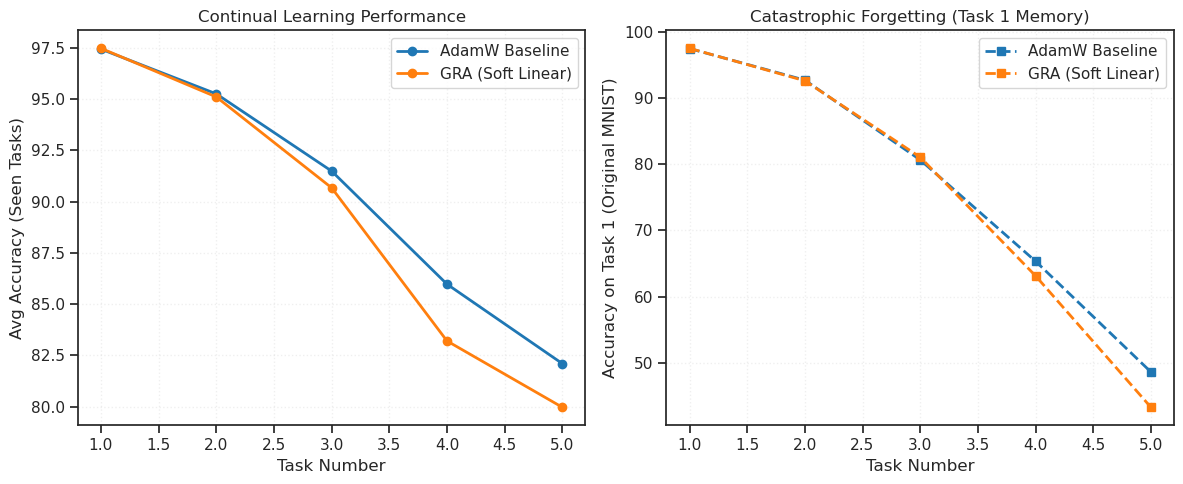

Optimizer            | Final Avg Acc   | Task 1 Retention

-------------------------------------------------------

AdamW Baseline       | 82.09          % | 48.62          %

GRA (Soft Linear)    | 79.96          % | 43.29          %

In [112]:
configs = [{'type': 'Standard', 'label': 'AdamW Baseline'}]

lambdas = [0.05, 0.07, 0.1, 0.5]
taus = [0.01, 0.05, 0.1, 0.2, 0.4, 0.5]

for lamb, tau in itertools.product(lambdas, taus):
    configs.append({
        'type': 'GRA',
        'label': f'GRA (lambda:{lamb},tau:{tau})',
        'lambda': lamb,
        'tau': tau,
    })
    
len(configs)

25

In [113]:
%%time

results = {}

for conf in configs:
    matrix = run_permuted_mnist(conf, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5)
    results[conf['label']] = matrix

--- Running AdamW Baseline ---
{'type': 'Standard', 'label': 'AdamW Baseline'}

Training Task 1/5...

> Acc on Task 1 (Original): 97.51%

> Acc on Task 1 (Current):  97.51%

Training Task 2/5...

...

> Acc on Task 4 (Current):  97.69%

Training Task 5/5...

> Acc on Task 1 (Original): 50.72%

> Acc on Task 5 (Current):  97.62%

CPU times: user 10min 25s, sys: 3.88 s, total: 10min 28s
Wall time: 10min 34s


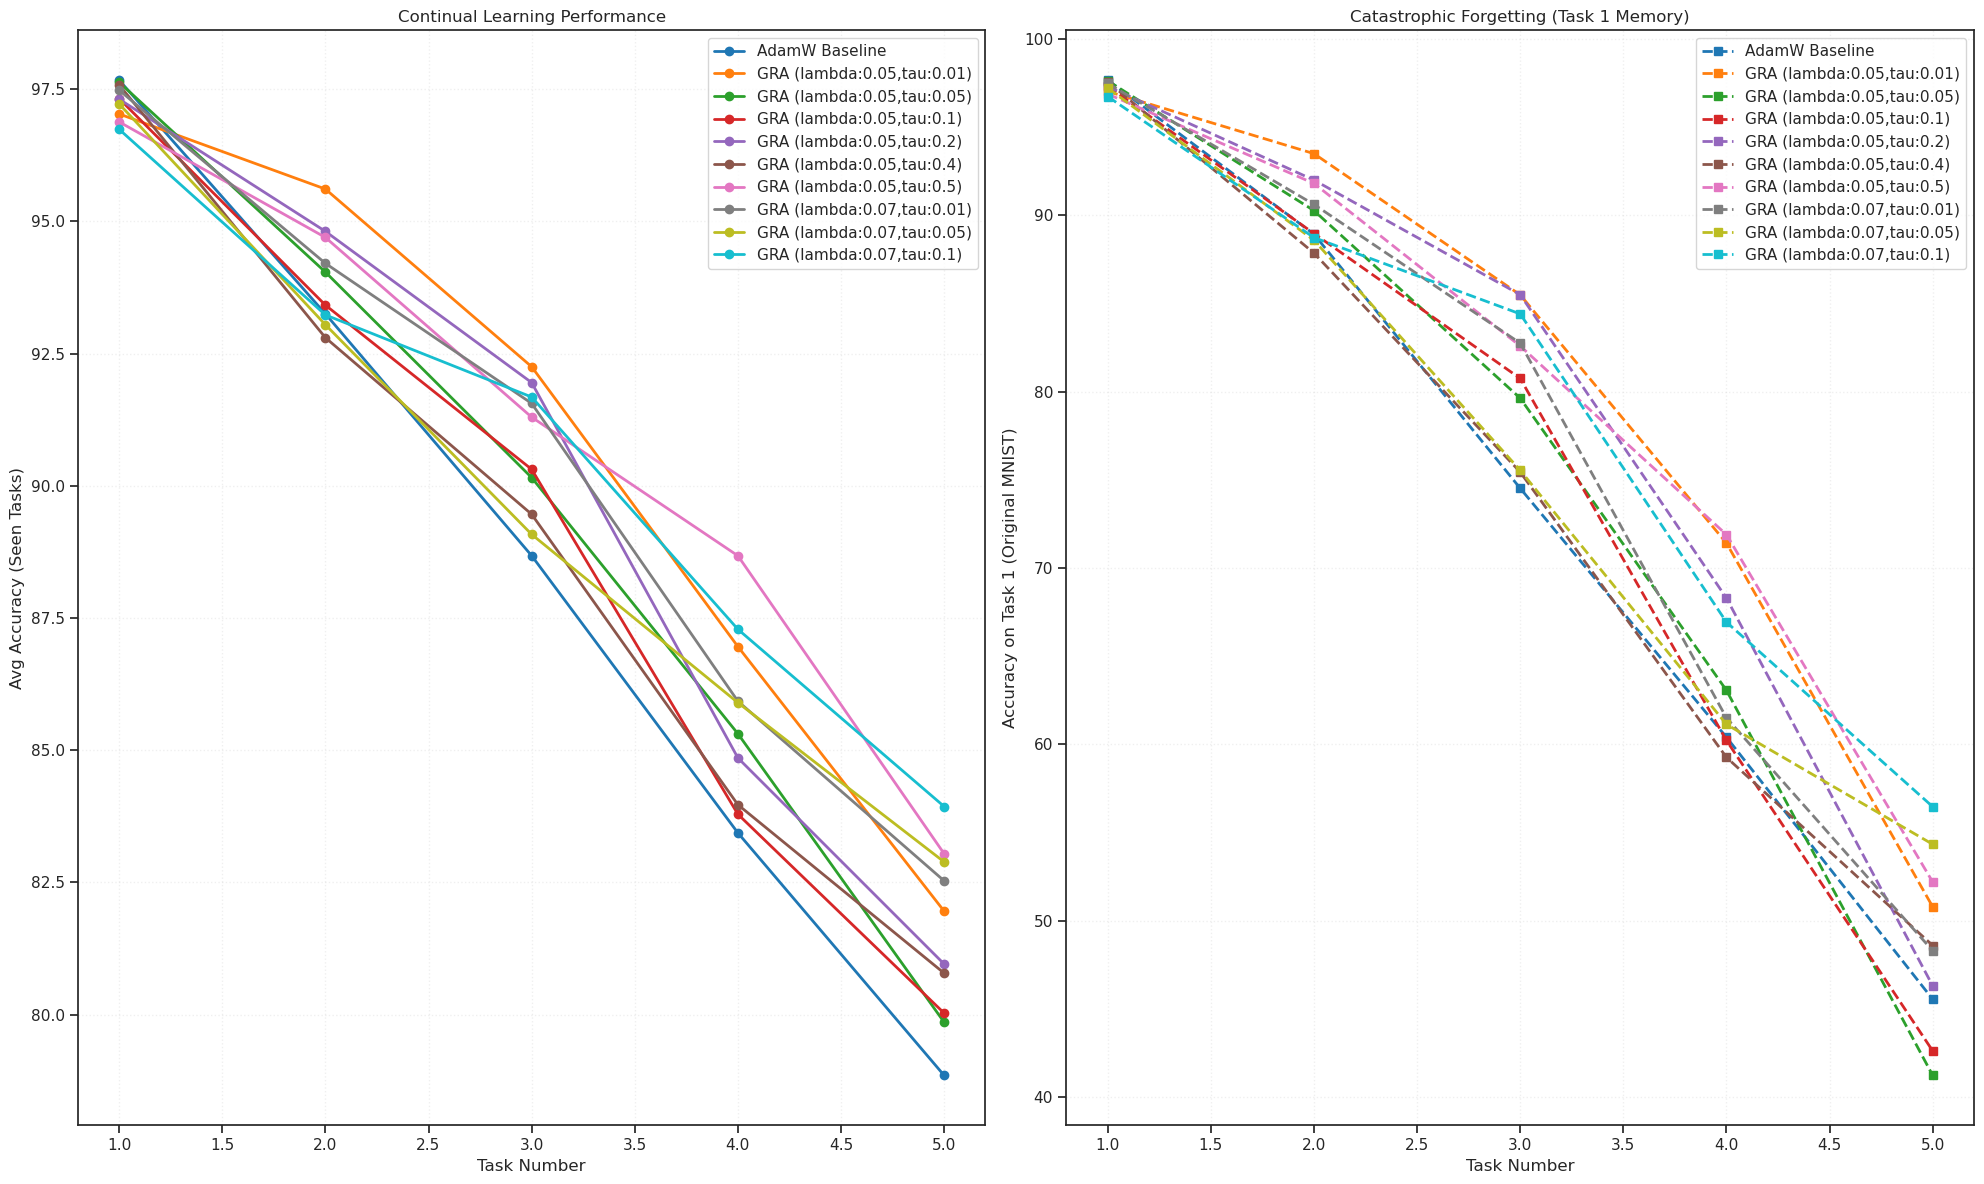

Optimizer            | Final Avg Acc   | Task 1 Retention

-------------------------------------------------------

AdamW Baseline       | 78.85          % | 45.54          %

GRA (lambda:0.05,tau:0.01) | 81.95          % | 50.78          %

GRA (lambda:0.05,tau:0.05) | 79.85          % | 41.22          %

...

GRA (lambda:0.05,tau:0.4) | 80.78          % | 48.59          %

GRA (lambda:0.05,tau:0.5) | 83.04          % | 52.19          %

GRA (lambda:0.07,tau:0.01) | 82.53          % | 48.29          %

GRA (lambda:0.07,tau:0.05) | 82.89          % | 54.33          %

GRA (lambda:0.07,tau:0.1) | 83.93          % | 56.46          %

In [109]:
plt.figure(figsize=(20, 12))

# Plot 1: Average Accuracy over Time
plt.subplot(1, 2, 1)
for label, mat in results.items():
    n = mat.shape[0]
    # At step t, we care about average accuracy on tasks 0..t
    avg_acc = [np.mean(mat[t, :t+1]) for t in range(n)]
    plt.plot(range(1, n+1), avg_acc, '-o', label=label, linewidth=2)

plt.xlabel('Task Number')
plt.ylabel('Avg Accuracy (Seen Tasks)')
plt.title('Continual Learning Performance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Forgetting Task 1
plt.subplot(1, 2, 2)
for label, mat in results.items():
    # Track performance on Task 1 specifically as we learn more tasks
    task1_acc = mat[:, 0] 
    plt.plot(range(1, 6), task1_acc, '--s', label=label, linewidth=2)

plt.xlabel('Task Number')
plt.ylabel('Accuracy on Task 1 (Original MNIST)')
plt.title('Catastrophic Forgetting (Task 1 Memory)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Final Summary Table
print(f"\n{'Optimizer':<20} | {'Final Avg Acc':<15} | {'Task 1 Retention':<15}")
print("-" * 55)
for label, mat in results.items():
    n = mat.shape[0]
    final_avg = np.mean(mat[-1, :])
    task1_ret = mat[-1, 0]
    print(f"{label:<20} | {final_avg:<15.2f}% | {task1_ret:<15.2f}%")

In [112]:
configs = [{'type': 'Standard', 'label': 'AdamW Baseline'}]

lambdas = [0.05, 0.07, 0.1, 0.5]
taus = [0.01, 0.05, 0.1, 0.2, 0.4, 0.5]

for lamb, tau in itertools.product(lambdas, taus):
    configs.append({
        'type': 'GRA',
        'label': f'GRA (lambda:{lamb},tau:{tau})',
        'lambda': lamb,
        'tau': tau,
    })
    
len(configs)

25

In [113]:
%%time

results = {}

for conf in configs:
    matrix = run_permuted_mnist(conf, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5)
    results[conf['label']] = matrix

--- Running AdamW Baseline ---
{'type': 'Standard', 'label': 'AdamW Baseline'}

Training Task 1/5...

> Acc on Task 1 (Original): 97.51%

> Acc on Task 1 (Current):  97.51%

Training Task 2/5...

...

> Acc on Task 4 (Current):  97.69%

Training Task 5/5...

> Acc on Task 1 (Original): 50.72%

> Acc on Task 5 (Current):  97.62%

CPU times: user 10min 25s, sys: 3.88 s, total: 10min 28s
Wall time: 10min 34s


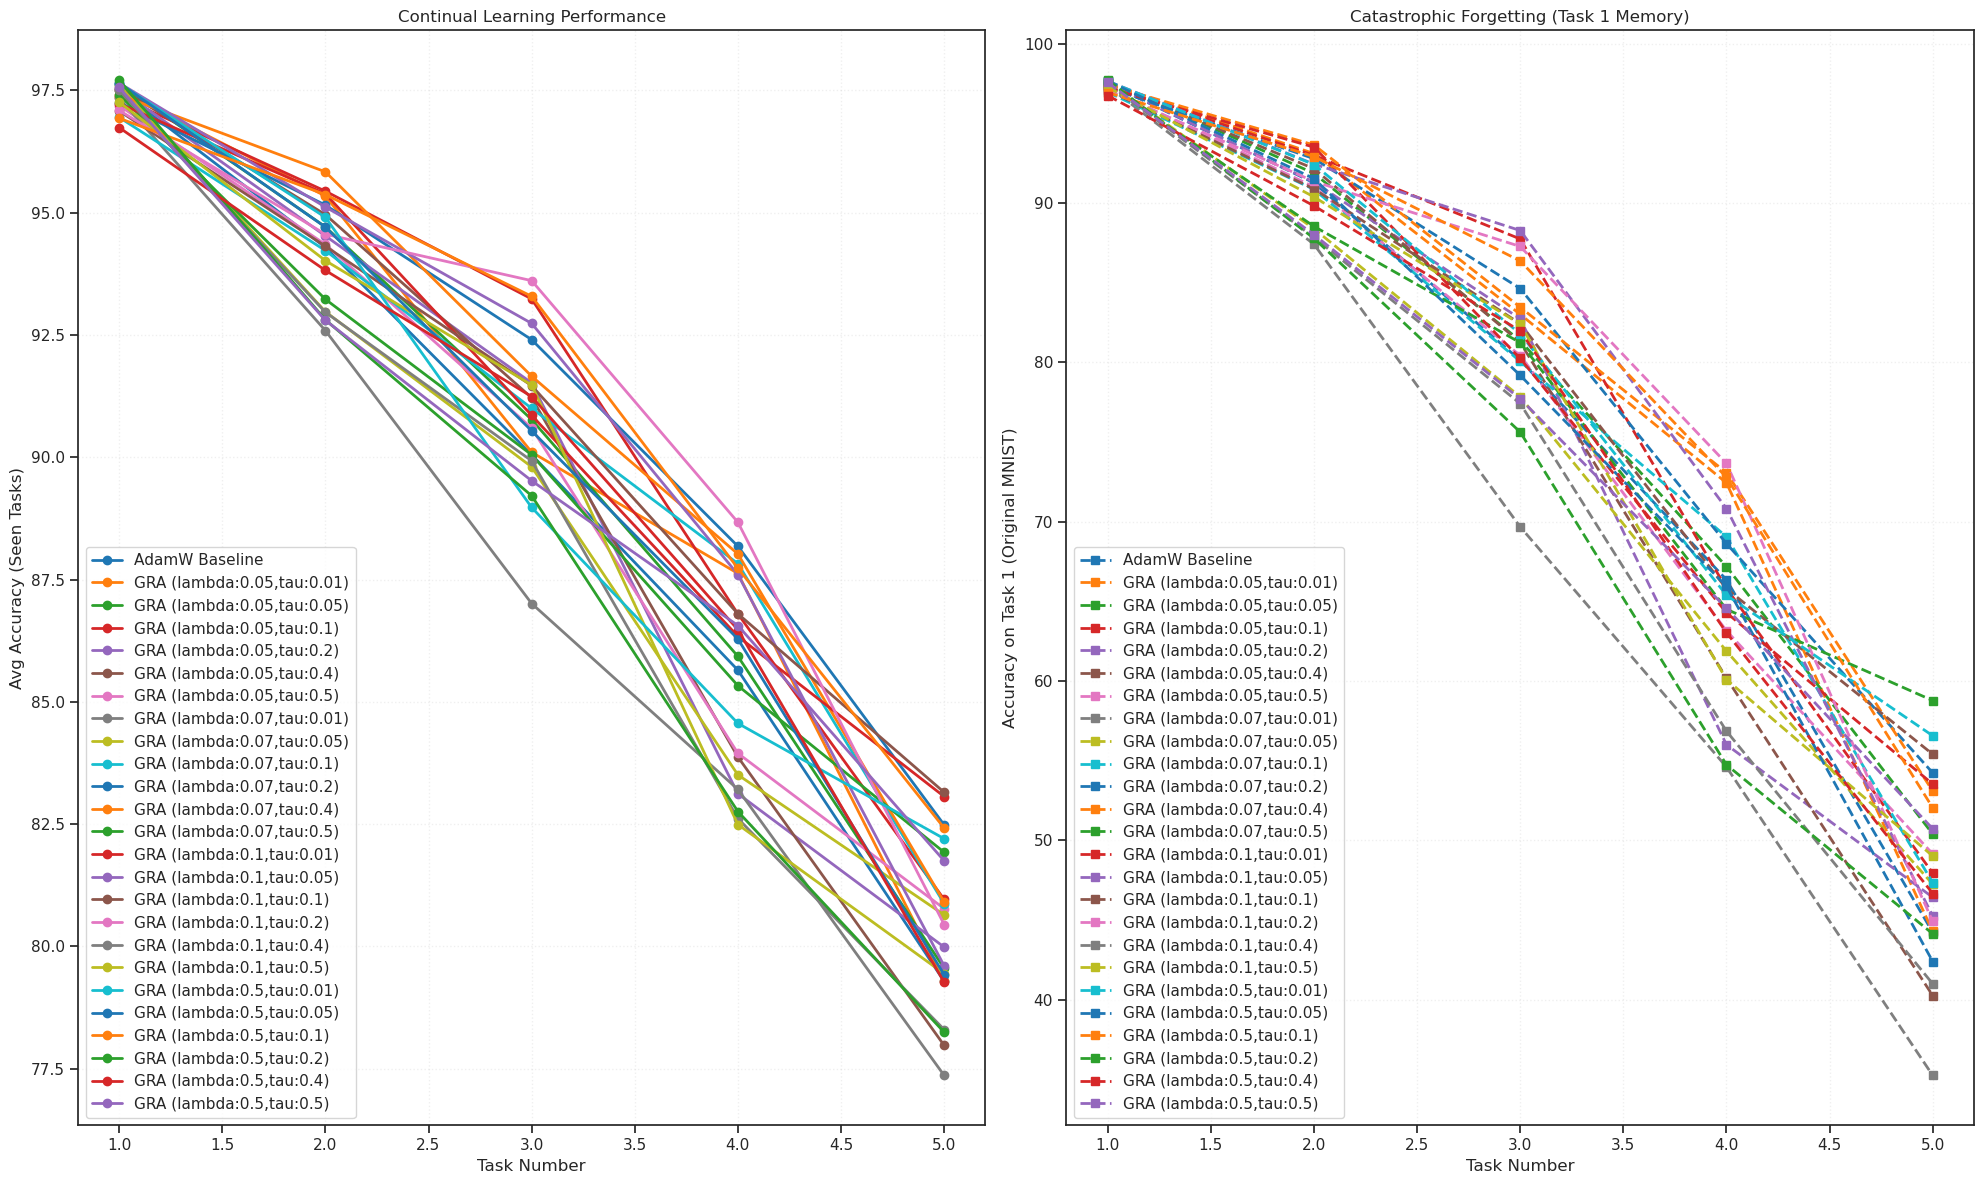

Optimizer            | Final Avg Acc   | Task 1 Retention

-------------------------------------------------------

AdamW Baseline       | 79.29          % | 44.22          %

GRA (lambda:0.05,tau:0.01) | 79.29          % | 44.28          %

GRA (lambda:0.05,tau:0.05) | 79.55          % | 50.39          %

...

GRA (lambda:0.5,tau:0.05) | 79.42          % | 42.39          %

GRA (lambda:0.5,tau:0.1) | 82.42          % | 52.04          %

GRA (lambda:0.5,tau:0.2) | 78.25          % | 44.13          %

GRA (lambda:0.5,tau:0.4) | 79.27          % | 46.66          %

GRA (lambda:0.5,tau:0.5) | 81.75          % | 50.72          %

In [114]:
plt.figure(figsize=(20, 12))

# Plot 1: Average Accuracy over Time
plt.subplot(1, 2, 1)
for label, mat in results.items():
    n = mat.shape[0]
    # At step t, we care about average accuracy on tasks 0..t
    avg_acc = [np.mean(mat[t, :t+1]) for t in range(n)]
    plt.plot(range(1, n+1), avg_acc, '-o', label=label, linewidth=2)

plt.xlabel('Task Number')
plt.ylabel('Avg Accuracy (Seen Tasks)')
plt.title('Continual Learning Performance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Forgetting Task 1
plt.subplot(1, 2, 2)
for label, mat in results.items():
    # Track performance on Task 1 specifically as we learn more tasks
    task1_acc = mat[:, 0] 
    plt.plot(range(1, 6), task1_acc, '--s', label=label, linewidth=2)

plt.xlabel('Task Number')
plt.ylabel('Accuracy on Task 1 (Original MNIST)')
plt.title('Catastrophic Forgetting (Task 1 Memory)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Final Summary Table
print(f"\n{'Optimizer':<20} | {'Final Avg Acc':<15} | {'Task 1 Retention':<15}")
print("-" * 55)
for label, mat in results.items():
    n = mat.shape[0]
    final_avg = np.mean(mat[-1, :])
    task1_ret = mat[-1, 0]
    print(f"{label:<20} | {final_avg:<15.2f}% | {task1_ret:<15.2f}%")

## Blurry permuted MNIST

In [126]:
class MLP(nn.Module):
    def __init__(self, hidden_size=256): # Reduced capacity to force interference
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def get_permutations(n_tasks, input_dim=784, seed=42):
    perms = []
    perms.append(torch.arange(input_dim).to(device)) # Task 1 is Identity
    rng = torch.Generator().manual_seed(seed)
    for _ in range(n_tasks - 1):
        perms.append(torch.randperm(input_dim, generator=rng).to(device))
    return perms

def apply_perm(x, perm):
    b = x.size(0)
    x_flat = x.view(b, -1)
    return x_flat[:, perm]

# ==========================================
# 2. The Forgetting Curve Experiment
# ==========================================
def run_forgetting_curve(opt_config, trn_loader, vld_loader, n_tasks=5, epochs_per_task=4):
    print(f"\n--- Running {opt_config['label']} ---")
    
    model = MLP(hidden_size=256).to(device) # Smaller model
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    if opt_config['type'] == 'GRA':
        optimizer = RelativisticMemoryOptimizer(
            base_opt, 
            memory_timescale=opt_config['tau'],
            coupling_strength=opt_config['lambda']
        )
    else:
        optimizer = base_opt

    criterion = nn.CrossEntropyLoss()
    perms = get_permutations(n_tasks)
    
    # We want to track Task 1 Accuracy at every step
    task1_history = []
    task1_perm = perms[0]
    
    total_steps = 0
    
    for task_idx in range(n_tasks):
        current_perm = perms[task_idx]
        print(f"Starting Task {task_idx+1}...")
        
        for epoch in range(epochs_per_task):
            model.train()
            for x, y in trn_loader:
                x, y = x.to(device), y.to(device)
                x_perm = apply_perm(x, current_perm)
                
                optimizer.zero_grad()
                loss = criterion(model(x_perm), y.long())
                loss.backward()
                optimizer.step()
                total_steps += 1
            
            # --- EVALUATE TASK 1 AFTER EVERY EPOCH ---
            model.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x_p1 = apply_perm(x, task1_perm) # Always test on Task 1
                    pred = model(x_p1).argmax(1)
                    correct += (pred == y).sum().item()
                    total += y.size(0)
            
            acc = 100.0 * correct / total
            task1_history.append(acc)
            # print(f"  Epoch {epoch+1}: Task 1 Acc = {acc:.2f}%")

    return task1_history

In [129]:
configs = [
    {'type': 'Standard', 'label': 'AdamW (Baseline)'},
    # Use the specific setting that gave 56 % retention in your table
    {'type': 'GRA', 'label': 'GRA (Soft Linear)', 'lambda': 0.1, 'tau': 0.01}
]

results = {}
for conf in configs:
    results[conf['label']] = run_forgetting_curve(conf, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5)


--- Running AdamW (Baseline) ---

Starting Task 1...

Starting Task 2...

Starting Task 3...

Starting Task 4...

...

Starting Task 1...

Starting Task 2...

Starting Task 3...

Starting Task 4...

Starting Task 5...

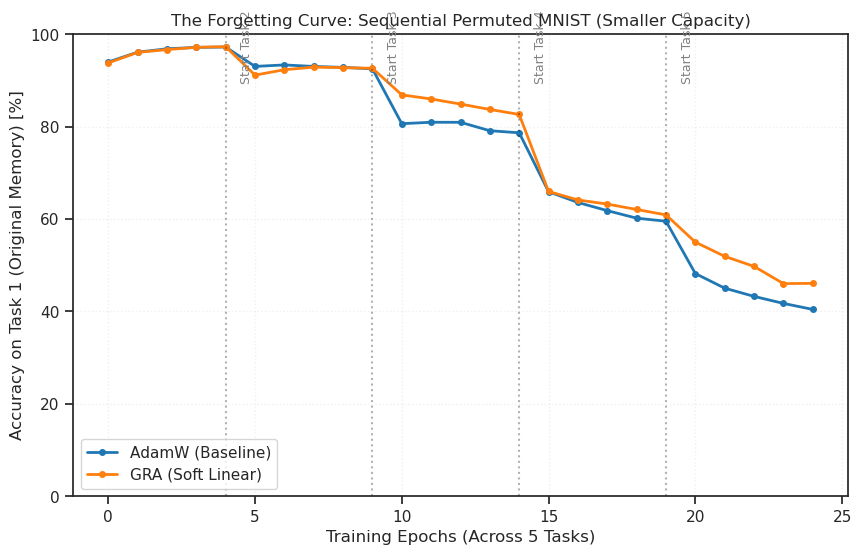

Optimizer            | Start Acc  | End Acc    | Drop

-------------------------------------------------------

AdamW (Baseline)     | 97.23      | 40.44      | 56.79

GRA (Soft Linear)    | 97.31      | 46.08      | 51.23

In [130]:
plt.figure(figsize=(10, 6))

for label, history in results.items():
    plt.plot(history, '-o', label=label, linewidth=2, markersize=4)

# Add Task Boundaries visual
epochs_per_task = 5
total_epochs = len(next(iter(results.values())))
for i in range(1, 5):
    boundary = i * epochs_per_task - 1
    plt.axvline(boundary, color='k', linestyle=':', alpha=0.3)
    plt.text(boundary + 0.5, 90, f'Start Task {i+1}', fontsize=9, rotation=90, color='gray')

plt.xlabel('Training Epochs (Across 5 Tasks)')
plt.ylabel('Accuracy on Task 1 (Original Memory) [%]')
plt.title('The Forgetting Curve: Sequential Permuted MNIST (Smaller Capacity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.show()

# Print Final Drop
print(f"\n{'Optimizer':<20} | {'Start Acc':<10} | {'End Acc':<10} | {'Drop':<10}")
print("-" * 55)
for label, h in results.items():
    start = h[epochs_per_task-1] # End of Task 1 training
    end = h[-1]
    print(f"{label:<20} | {start:<10.2f} | {end:<10.2f} | {start-end:<10.2f}")

In [131]:
configs = [
    {'type': 'Standard', 'label': 'AdamW (Baseline)'},
    # Use the specific setting that gave 56 % retention in your table
    {'type': 'GRA', 'label': 'GRA (Soft Linear)', 'lambda': 0.2, 'tau': 0.01}
]

results = {}
for conf in configs:
    results[conf['label']] = run_forgetting_curve(conf, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5)


--- Running AdamW (Baseline) ---

Starting Task 1...

Starting Task 2...

Starting Task 3...

Starting Task 4...

...

Starting Task 1...

Starting Task 2...

Starting Task 3...

Starting Task 4...

Starting Task 5...

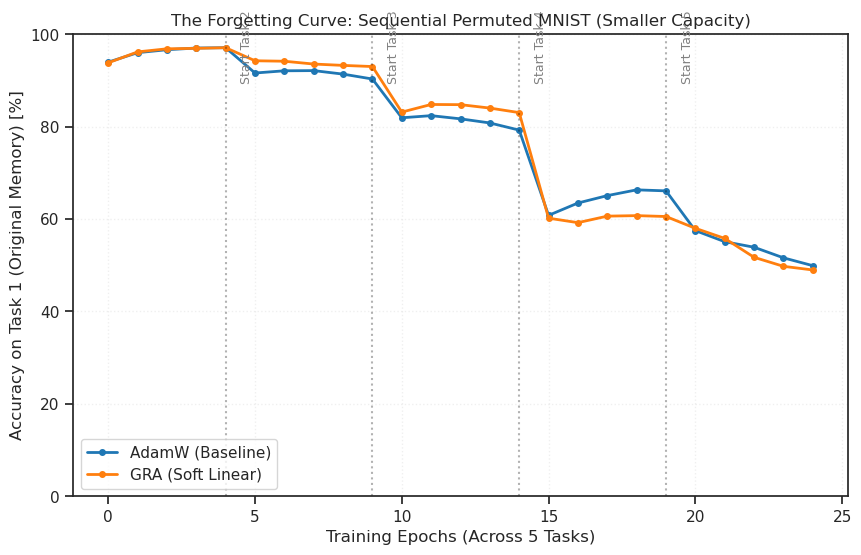

Optimizer            | Start Acc  | End Acc    | Drop

-------------------------------------------------------

AdamW (Baseline)     | 97.09      | 49.91      | 47.18

GRA (Soft Linear)    | 97.09      | 48.98      | 48.11

In [132]:
plt.figure(figsize=(10, 6))

for label, history in results.items():
    plt.plot(history, '-o', label=label, linewidth=2, markersize=4)

# Add Task Boundaries visual
epochs_per_task = 5
total_epochs = len(next(iter(results.values())))
for i in range(1, 5):
    boundary = i * epochs_per_task - 1
    plt.axvline(boundary, color='k', linestyle=':', alpha=0.3)
    plt.text(boundary + 0.5, 90, f'Start Task {i+1}', fontsize=9, rotation=90, color='gray')

plt.xlabel('Training Epochs (Across 5 Tasks)')
plt.ylabel('Accuracy on Task 1 (Original Memory) [%]')
plt.title('The Forgetting Curve: Sequential Permuted MNIST (Smaller Capacity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.show()

# Print Final Drop
print(f"\n{'Optimizer':<20} | {'Start Acc':<10} | {'End Acc':<10} | {'Drop':<10}")
print("-" * 55)
for label, h in results.items():
    start = h[epochs_per_task-1] # End of Task 1 training
    end = h[-1]
    print(f"{label:<20} | {start:<10.2f} | {end:<10.2f} | {start-end:<10.2f}")

### t-test

In [133]:
class MLP(nn.Module):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def apply_perm(x, perm):
    b = x.size(0)
    x_flat = x.view(b, -1)
    return x_flat[:, perm]

def get_permutations(n_tasks, input_dim=784, seed=42):
    perms = []
    perms.append(torch.arange(input_dim).to(device))
    rng = torch.Generator().manual_seed(seed)
    for _ in range(n_tasks - 1):
        perms.append(torch.randperm(input_dim, generator=rng).to(device))
    return perms

# ==========================================
# 2. Experiment Runner (Single Seed)
# ==========================================
def run_trial(opt_config, trn_loader, vld_loader, seed, n_tasks=5, epochs_per_task=5):
    # Set Seed for Reproducibility within this trial
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = MLP(hidden_size=256).to(device)
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    if opt_config['type'] == 'GRA':
        optimizer = RelativisticMemoryOptimizer(
            base_opt, 
            memory_timescale=opt_config['tau'],
            coupling_strength=opt_config['lambda']
        )
    else:
        optimizer = base_opt

    criterion = nn.CrossEntropyLoss()
    perms = get_permutations(n_tasks, seed=42) # Fixed perms for fair comparison across seeds
    
    task1_perm = perms[0]
    history = []
    
    for task_idx in range(n_tasks):
        current_perm = perms[task_idx]
        
        for epoch in range(epochs_per_task):
            model.train()
            for x, y in trn_loader:
                x, y = x.to(device), y.to(device)
                x_perm = apply_perm(x, current_perm)
                
                optimizer.zero_grad()
                loss = criterion(model(x_perm), y.long())
                loss.backward()
                optimizer.step()
            
            # Eval Task 1
            model.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x_p1 = apply_perm(x, task1_perm)
                    pred = model(x_p1).argmax(1)
                    correct += (pred == y).sum().item()
                    total += y.size(0)
            
            acc = 100.0 * correct / total
            history.append(acc)
            
    return np.array(history)

Running 10 statistical trials per config...

--> Config: AdamW (Baseline)

Trial 1/10 | Final T1 Acc: 38.85%

Trial 2/10 | Final T1 Acc: 41.73%

Trial 3/10 | Final T1 Acc: 49.63%

...

Trial 6/10 | Final T1 Acc: 44.94%

Trial 7/10 | Final T1 Acc: 46.61%

Trial 8/10 | Final T1 Acc: 42.46%

Trial 9/10 | Final T1 Acc: 61.09%

Trial 10/10 | Final T1 Acc: 47.64%

In [136]:
from scipy import stats

In [137]:
# ==========================================
# 4. Statistical T-Test
# ==========================================
print("\n=== Statistical Significance Test (Welch's t-test) ===")
baseline_scores = final_scores['AdamW (Baseline)']
gra_scores = final_scores['GRA (Soft Linear)']

t_stat, p_val = stats.ttest_ind(gra_scores, baseline_scores, equal_var=False)

print(f"AdamW Mean Final Acc: {np.mean(baseline_scores):.2f} +/- {np.std(baseline_scores):.2f}")
print(f"GRA   Mean Final Acc: {np.mean(gra_scores):.2f} +/- {np.std(gra_scores):.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4e}")

if p_val < 0.05:
    print("RESULT: Statistically Significant Improvement (p < 0.05)")
else:
    print("RESULT: Not Statistically Significant")


=== Statistical Significance Test (Welch's t-test) ===

AdamW Mean Final Acc: 46.60 +/- 7.22

GRA   Mean Final Acc: 46.60 +/- 7.22

T-Statistic: 0.0000

P-Value:     1.0000e+00

RESULT: Not Statistically Significant

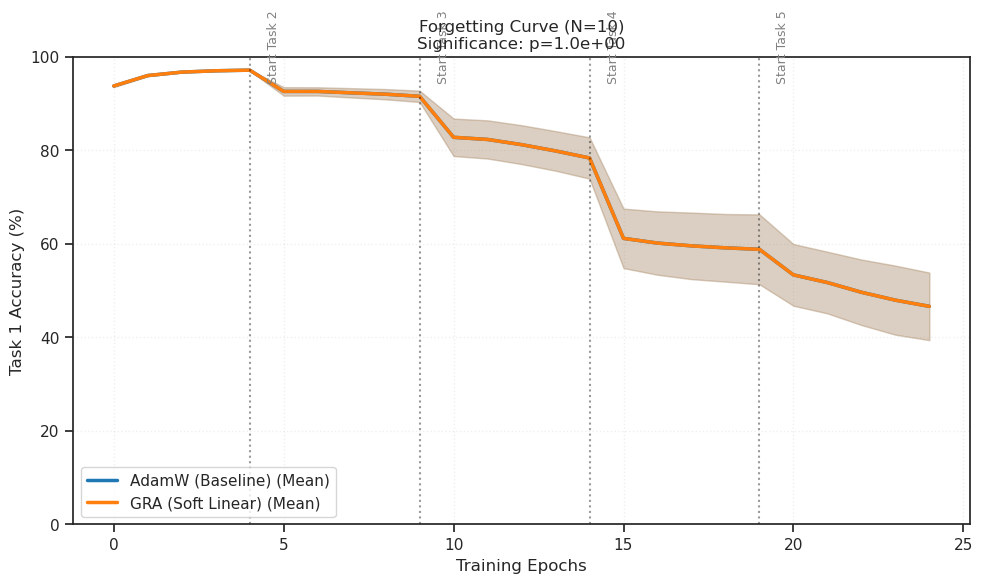

In [138]:
# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

epochs_per_task = 5
total_epochs = len(results_agg['AdamW (Baseline)']['mean'])
x_axis = range(total_epochs)

for label, data in results_agg.items():
    mean = data['mean']
    std = data['std']
    color = data['color']
    
    plt.plot(x_axis, mean, label=f"{label} (Mean)", color=color, linewidth=2.5)
    plt.fill_between(x_axis, mean - std, mean + std, color=color, alpha=0.2)

# Draw Task Boundaries
for i in range(1, 5):
    boundary = i * epochs_per_task - 1
    plt.axvline(boundary, color='k', linestyle=':', alpha=0.4)
    plt.text(boundary + 0.5, 95, f'Start Task {i+1}', fontsize=9, rotation=90, color='gray')

plt.xlabel('Training Epochs')
plt.ylabel('Task 1 Accuracy (%)')
plt.title(f'Forgetting Curve (N={N_TRIALS})\nSignificance: p={p_val:.1e}')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [150]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# ==========================================
# 1. The Validated Optimizer (Clean)
# ==========================================
class RelativisticMemoryOptimizer(torch.optim.Optimizer):
    def __init__(self, base_optimizer, memory_timescale=0.01, coupling_strength=1.0):
        self.base_optimizer = base_optimizer
        self.tau = memory_timescale
        self.lamb = coupling_strength
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = self.base_optimizer.defaults
        self.state = self.base_optimizer.state

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        self._update_memory_and_force()
        self.base_optimizer.step()
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def _update_memory_and_force(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                if p not in self.state: continue
                state = self.state[p]
                if len(state) == 0: continue
                
                # Init Memory (Step 1+)
                if 'phi_field' not in state:
                    state['phi_field'] = p.detach().clone()
                    continue
                
                phi = state['phi_field']
                
                # Apply Force (Linear Spring)
                # p.grad += lambda * (theta - phi)
                restoring_force = self.lamb * (p - phi)
                p.grad.add_(restoring_force)
                
                # Update Memory
                phi.add_(p - phi, alpha=self.tau)

# ==========================================
# 2. Experiment Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_permutations(n_tasks, input_dim=784, seed=42):
    perms = [torch.arange(input_dim).to(device)]
    rng = torch.Generator().manual_seed(seed)
    for _ in range(n_tasks - 1):
        perms.append(torch.randperm(input_dim, generator=rng).to(device))
    return perms

def apply_perm(x, perm):
    b = x.size(0)
    return x.view(b, -1)[:, perm]

class MLP(nn.Module):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 10)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def run_forgetting_curve(opt_config, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5):
    print(f"\n--- Running {opt_config['label']} ---")
    
    model = MLP(hidden_size=256).to(device)
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    if opt_config['type'] == 'GRA':
        optimizer = RelativisticMemoryOptimizer(
            base_opt, 
            memory_timescale=opt_config['tau'],
            coupling_strength=opt_config['lambda']
        )
    else:
        optimizer = base_opt

    criterion = nn.CrossEntropyLoss()
    perms = get_permutations(n_tasks)
    task1_perm = perms[0]
    task1_history = []
    
    for task_idx in range(n_tasks):
        curr_perm = perms[task_idx]
        print(f"Task {task_idx+1}...", end=" ")
        
        for epoch in range(epochs_per_task):
            model.train()
            for x, y in trn_loader:
                x, y = x.to(device), y.to(device)
                x = apply_perm(x, curr_perm)
                
                optimizer.zero_grad()
                loss = criterion(model(x), y.long())
                loss.backward()
                optimizer.step()
            
            # Eval Task 1
            model.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x = apply_perm(x, task1_perm)
                    pred = model(x).argmax(1)
                    correct += (pred == y).sum().item()
                    total += y.size(0)
            task1_history.append(100.0 * correct / total)
        print("Done.")

    return task1_history

In [153]:
# Configs: Bracket the optimal Lambda
configs = [
    {'type': 'Standard', 'label': 'AdamW (Baseline)'},
    {'type': 'GRA', 'label': 'GRA (Lambda=0.1,tau=0.01)', 'lambda': 0.1, 'tau': 0.01},
    {'type': 'GRA', 'label': 'GRA (Lambda=0.5,tau=0.01)', 'lambda': 0.5, 'tau': 0.01},
    {'type': 'GRA', 'label': 'GRA (Lambda=1.0,tau=0.01)', 'lambda': 1.0, 'tau': 0.01},
    {'type': 'GRA', 'label': 'GRA (Lambda=1.0,tau=0.1)', 'lambda': 1.0, 'tau': 0.1},
]

results = {}
for conf in configs:
    results[conf['label']] = run_forgetting_curve(conf, trn_loader, vld_loader, n_tasks=5, epochs_per_task=5)


--- Running AdamW (Baseline) ---

Task 1...

Done.

Task 2...

Done.

...

Done.

Task 4...

Done.

Task 5...

Done.

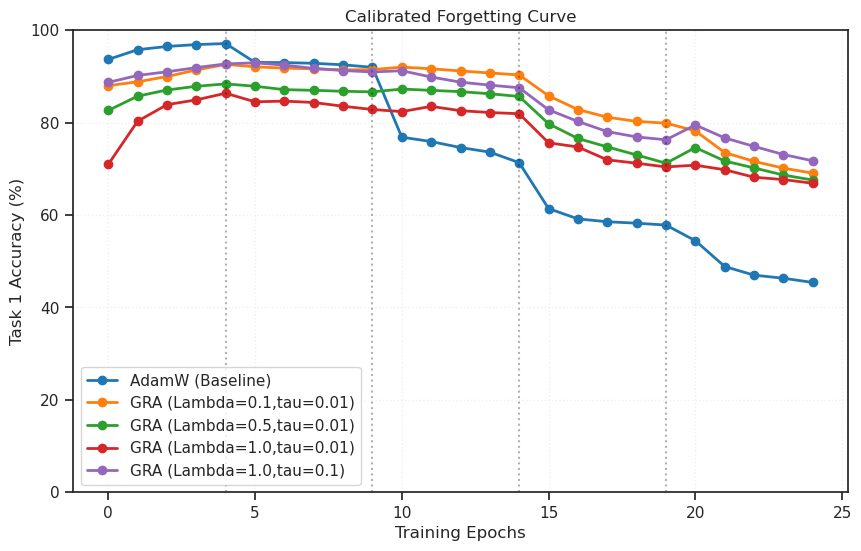

Optimizer            | Start Acc  | End Acc    | Drop

-------------------------------------------------------

AdamW (Baseline)     | 97.12      | 45.41      | 51.71

GRA (Lambda=0.1,tau=0.01) | 92.60      | 69.07      | 23.53

GRA (Lambda=0.5,tau=0.01) | 88.39      | 67.57      | 20.82

GRA (Lambda=1.0,tau=0.01) | 86.37      | 66.88      | 19.49

GRA (Lambda=1.0,tau=0.1) | 92.72      | 71.74      | 20.98

In [154]:
# Plot
plt.figure(figsize=(10, 6))
for label, history in results.items():
    plt.plot(history, '-o', label=label, linewidth=2)

epochs_per_task = 5
for i in range(1, 5):
    boundary = i * epochs_per_task - 1
    plt.axvline(boundary, color='k', linestyle=':', alpha=0.3)

plt.xlabel('Training Epochs')
plt.ylabel('Task 1 Accuracy (%)')
plt.title('Calibrated Forgetting Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.show()

# Print Table
print(f"\n{'Optimizer':<20} | {'Start Acc':<10} | {'End Acc':<10} | {'Drop':<10}")
print("-" * 55)
for label, h in results.items():
    start = h[epochs_per_task-1]
    end = h[-1]
    print(f"{label:<20} | {start:<10.2f} | {end:<10.2f} | {start-end:<10.2f}")

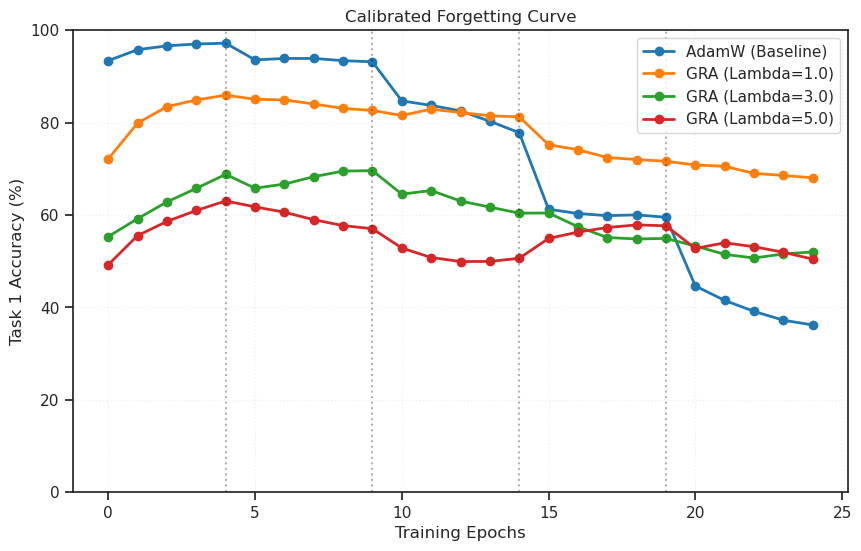

Optimizer            | Start Acc  | End Acc    | Drop

-------------------------------------------------------

AdamW (Baseline)     | 97.20      | 36.21      | 60.99

GRA (Lambda=1.0)     | 85.94      | 68.06      | 17.88

GRA (Lambda=3.0)     | 68.81      | 52.02      | 16.79

GRA (Lambda=5.0)     | 63.05      | 50.46      | 12.59

In [155]:
class MLP(nn.Module):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def apply_perm(x, perm):
    b = x.size(0)
    return x.view(b, -1)[:, perm]

def get_permutations(n_tasks, input_dim=784, seed=42):
    perms = [torch.arange(input_dim).to(device)] # Task 1 is Identity
    rng = torch.Generator().manual_seed(seed)
    for _ in range(n_tasks - 1):
        perms.append(torch.randperm(input_dim, generator=rng).to(device))
    return perms

# ==========================================
# 2. The Long Run Execution
# ==========================================
def run_long_experiment(lambda_val=1.0, tau_val=0.1, epochs_per_task=20):
    print(f"\n--- Starting Long Run (Lambda={lambda_val},Tau={tau_val}) - Epochs/Task={epochs_per_task}) ---")
    
    # 1. Initialize Model & Optimizer
    model = MLP(hidden_size=256).to(device)
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    # Using the class you already have in memory
    optimizer = RelativisticMemoryOptimizer(
        base_opt, 
        memory_timescale=0.01, 
        coupling_strength=lambda_val
    )
    
    criterion = nn.CrossEntropyLoss()
    n_tasks = 5
    perms = get_permutations(n_tasks)
    
    # Metrics
    history_task1 = []
    history_current = []
    
    # 2. Training Loop
    total_epoch = 0
    
    for task_idx in range(n_tasks):
        current_perm = perms[task_idx]
        print(f"\n>>> Starting Task {task_idx+1} (Epochs {total_epoch+1}-{total_epoch+epochs_per_task})")
        
        for epoch in range(epochs_per_task):
            model.train()
            train_loss = 0
            
            # Batch Training
            for x, y in trn_loader:
                x, y = x.to(device), y.to(device)
                x_p = apply_perm(x, current_perm)
                
                optimizer.zero_grad()
                loss = criterion(model(x_p), y.long())
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            # --- Evaluation Step ---
            model.eval()
            
            # 1. Check Task 1 (Memory)
            correct_t1 = 0; total_t1 = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x_p1 = apply_perm(x, perms[0])
                    pred = model(x_p1).argmax(1)
                    correct_t1 += (pred == y).sum().item()
                    total_t1 += y.size(0)
            acc_t1 = 100.0 * correct_t1 / total_t1
            history_task1.append(acc_t1)
            
            # 2. Check Current Task (Plasticity)
            correct_curr = 0; total_curr = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x_pc = apply_perm(x, current_perm)
                    pred = model(x_pc).argmax(1)
                    correct_curr += (pred == y).sum().item()
                    total_curr += y.size(0)
            acc_curr = 100.0 * correct_curr / total_curr
            history_current.append(acc_curr)
            
            total_epoch += 1
            print(f"    Epoch {epoch+1}/{epochs_per_task} | Task 1 Acc: {acc_t1:.2f}% | Current Task Acc: {acc_curr:.2f}%")

    return history_task1, history_current

--- Starting Long Run (Lambda=1.0,Tau=0.1) - Epochs/Task=20) ---

>>> Starting Task 1 (Epochs 1-20)

Epoch 1/20 | Task 1 Acc: 73.36% | Current Task Acc: 73.36%

Epoch 2/20 | Task 1 Acc: 81.42% | Current Task Acc: 81.42%

Epoch 3/20 | Task 1 Acc: 84.40% | Current Task Acc: 84.40%

...

Epoch 16/20 | Task 1 Acc: 68.77% | Current Task Acc: 94.02%

Epoch 17/20 | Task 1 Acc: 68.49% | Current Task Acc: 94.14%

Epoch 18/20 | Task 1 Acc: 68.25% | Current Task Acc: 94.26%

Epoch 19/20 | Task 1 Acc: 67.84% | Current Task Acc: 94.39%

Epoch 20/20 | Task 1 Acc: 67.61% | Current Task Acc: 94.52%

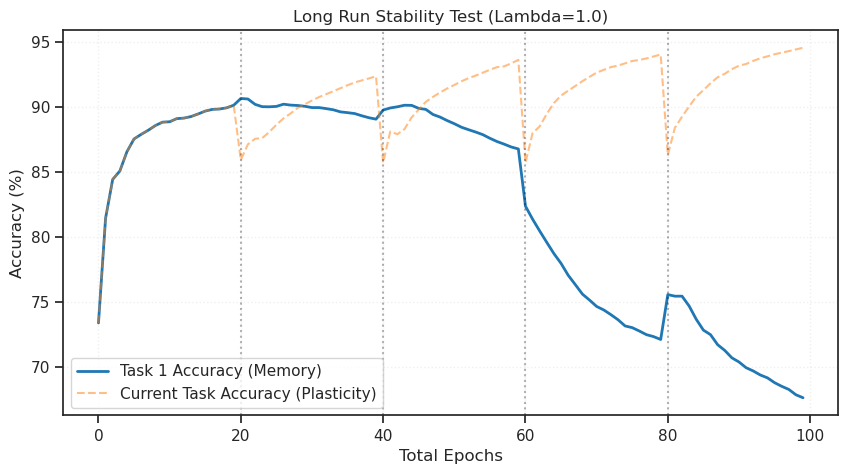

In [156]:
hist_mem, hist_plast = run_long_experiment(lambda_val=1.0, tau_val=0.1, epochs_per_task=20)

# Quick Plot
plt.figure(figsize=(10, 5))
plt.plot(hist_mem, label='Task 1 Accuracy (Memory)', linewidth=2)
plt.plot(hist_plast, label='Current Task Accuracy (Plasticity)', linestyle='--', alpha=0.5)
for i in range(1, 5):
    plt.axvline(i*20, color='k', linestyle=':', alpha=0.3)
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Long Run Stability Test (Lambda=1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### seeds + ttest

In [158]:
from tqdm.auto import tqdm  # Progress bar

In [161]:
def run_single_trial(config, seed, trn_loader, vld_loader, n_tasks=5):
    """Runs one complete Sequential MNIST experiment for a given config/seed."""
    
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Init Model
    model = MLP(hidden_size=256).to(device)
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    # Init Optimizer
    epochs = config.get('epochs', 5)
    
    if config['type'] == 'GRA':
        optimizer = RelativisticMemoryOptimizer(
            base_opt, 
            memory_timescale=config['tau'], 
            coupling_strength=config['lambda']
        )
    else:
        optimizer = base_opt # Standard AdamW

    criterion = nn.CrossEntropyLoss()
    # perms = get_permutations(n_tasks, seed=seed) # Diff perms per seed? Or fixed?
    # NOTE: Usually in papers, we fix the Permutations (Task definitions) 
    # and vary the Weight Initialization (Model seed). 
    # Here we use fixed perms for consistency across configs, but different model seeds.
    # To do that, we regenerate perms with a FIXED seed (e.g. 42) inside here, 
    # or pass them in. Let's fix perms to 42 for fair task comparison.
    perms = get_permutations(n_tasks, seed=42) 

    task1_perm = perms[0]
    history = []

    # Training Loop
    for task_idx in range(n_tasks):
        current_perm = perms[task_idx]
        
        for epoch in range(epochs):
            model.train()
            for x, y in trn_loader:
                x, y = x.to(device), y.to(device)
                x = apply_perm(x, current_perm)
                
                optimizer.zero_grad()
                loss = criterion(model(x), y.long())
                loss.backward()
                optimizer.step()
            
            # Metric: Task 1 Retention
            model.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x = apply_perm(x, task1_perm)
                    pred = model(x).argmax(1)
                    correct += (pred == y).sum().item()
                    total += y.size(0)
            
            acc = 100.0 * correct / total
            history.append(acc)
            
    return np.array(history)


def run_full_sweep(sweep_conf, trn_loader, vld_loader):
    results = {}
    
    # 1. Expand the Grid
    keys, values = zip(*sweep_conf['grid'].items())
    grid_permutations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    # 2. Build Experiment List (Baseline + Grid)
    experiments = []
    
    # Add Baseline
    for base in sweep_conf['baselines']:
        # Baseline needs an 'epochs' param too for the runner
        base_copy = base.copy()
        base_copy['epochs'] = sweep_conf['grid']['epochs'][0] # Default to first epoch setting
        experiments.append(base_copy)
        
    # Add Grid
    for params in grid_permutations:
        conf = params.copy()
        conf['type'] = 'GRA'
        conf['label'] = f"GRA (λ={params['lambda']}, τ={params['tau']})"
        experiments.append(conf)
        
    # 3. Run Loop
    print(f"Running {len(experiments)} Configurations across {len(sweep_conf['seeds'])} Seeds...")

    for conf in experiments:
        label = conf['label']
        print(f"--> Processing: {label}")
        
        trials = []
        for seed in tqdm(sweep_conf['seeds'], leave=False):
            hist = run_single_trial(conf, seed, trn_loader, vld_loader)
            trials.append(hist)
            
        # Stack: [N_SEEDS, TOTAL_EPOCHS]
        data_stack = np.stack(trials, axis=0)
        
        results[label] = {
            'mean': np.mean(data_stack, axis=0),
            'std':  np.std(data_stack, axis=0),
            'final_values': data_stack[:, -1], # For T-Test
            'config': conf
        }
        
    return results


def plot_sweep_results(results):
    plt.figure(figsize=(12, 7))
    
    # We need to find the Baseline stats for T-Testing
    baseline_key = next(k for k in results if 'Baseline' in k)
    base_finals = results[baseline_key]['final_values']
    
    print(f"\n{'Configuration':<30} | {'Final Acc (Mean ± Std)':<22} | {'p-value (vs Base)':<10} | {'Result'}")
    print("-" * 80)

    for label, res in results.items():
        mean = res['mean']
        std  = res['std']
        finals = res['final_values']
        epochs = len(mean)
        x_axis = range(epochs)
        
        # Plot
        # Distinguish Baseline with distinct style
        if 'Baseline' in label:
            plt.plot(x_axis, mean, '--', linewidth=3, label=label, color='black')
        else:
            p = plt.plot(x_axis, mean, linewidth=2, label=label)
            color = p[0].get_color()
            plt.fill_between(x_axis, mean - std, mean + std, color=color, alpha=0.15)
            
        # T-Test
        if label == baseline_key:
            p_val = 1.0
            sig = "N/A"
        else:
            t_stat, p_val = stats.ttest_ind(finals, base_finals, equal_var=False)
            sig = "*" if p_val < 0.05 else "ns"
            if p_val < 0.01: sig = "**"
            
        print(f"{label:<30} | {np.mean(finals):.2f}% ± {np.std(finals):.2f}%      | {p_val:.4f}     | {sig}")

    # Aesthetics
    # Assuming standard 5 tasks
    n_tasks = 5
    total_epochs = len(next(iter(results.values()))['mean'])
    epochs_per_task = total_epochs // n_tasks
    
    for i in range(1, n_tasks):
        boundary = i * epochs_per_task - 1
        plt.axvline(boundary, color='k', linestyle=':', alpha=0.3)
        plt.text(boundary+0.5, 95, f'Task {i+1}', fontsize=8, color='gray')

    plt.xlabel('Training Epochs')
    plt.ylabel('Task 1 Accuracy (%)')
    plt.title('Hyperparameter Sweep: Relativistic Memory vs Baseline')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.show()

In [162]:
SWEEP_CONFIG = {
    'seeds': [42, 43, 44, 45, 46],  # 5 seeds for statistical validity (N=5)
    
    # The Baseline (Always run this)
    'baselines': [
        {'label': 'AdamW (Baseline)', 'type': 'Standard'}
    ],
    
    # The Grid to Search
    'grid': {
        'lambda': [0.1, 0.5, 1.0, 2.0],             # Coupling Strength
        'tau':    [0.01, 0.05, 0.1, 0.2, 0.5],      # Memory Timescale
        'epochs': [40]                              # Epochs per task
    }
}

In [163]:
%%time


sweep_data = run_full_sweep(SWEEP_CONFIG, trn_loader, vld_loader)

Running 21 Configurations across 5 Seeds...

--> Processing: AdamW (Baseline)

  0%|          | 0/5 [00:00<?, ?it/s]

--> Processing: GRA (λ=0.1, τ=0.01)

  0%|          | 0/5 [00:00<?, ?it/s]

...

--> Processing: GRA (λ=2.0, τ=0.2)

  0%|          | 0/5 [00:00<?, ?it/s]

--> Processing: GRA (λ=2.0, τ=0.5)

  0%|          | 0/5 [00:00<?, ?it/s]

CPU times: user 5h 35min 42s, sys: 2min, total: 5h 37min 42s
Wall time: 5h 40min 51s


Configuration                  | Final Acc (Mean ± Std) | p-value (vs Base) | Result

--------------------------------------------------------------------------------

AdamW (Baseline)               | 19.90% ± 3.29%      | 1.0000     | N/A

GRA (λ=0.1, τ=0.01)            | 78.99% ± 2.55%      | 0.0000     | **

GRA (λ=0.1, τ=0.05)            | 64.45% ± 4.35%      | 0.0000     | **

...

GRA (λ=2.0, τ=0.01)            | 63.74% ± 1.78%      | 0.0000     | **

GRA (λ=2.0, τ=0.05)            | 77.67% ± 2.41%      | 0.0000     | **

GRA (λ=2.0, τ=0.1)             | 79.26% ± 3.81%      | 0.0000     | **

GRA (λ=2.0, τ=0.2)             | 76.34% ± 4.23%      | 0.0000     | **

GRA (λ=2.0, τ=0.5)             | 69.65% ± 3.94%      | 0.0000     | **

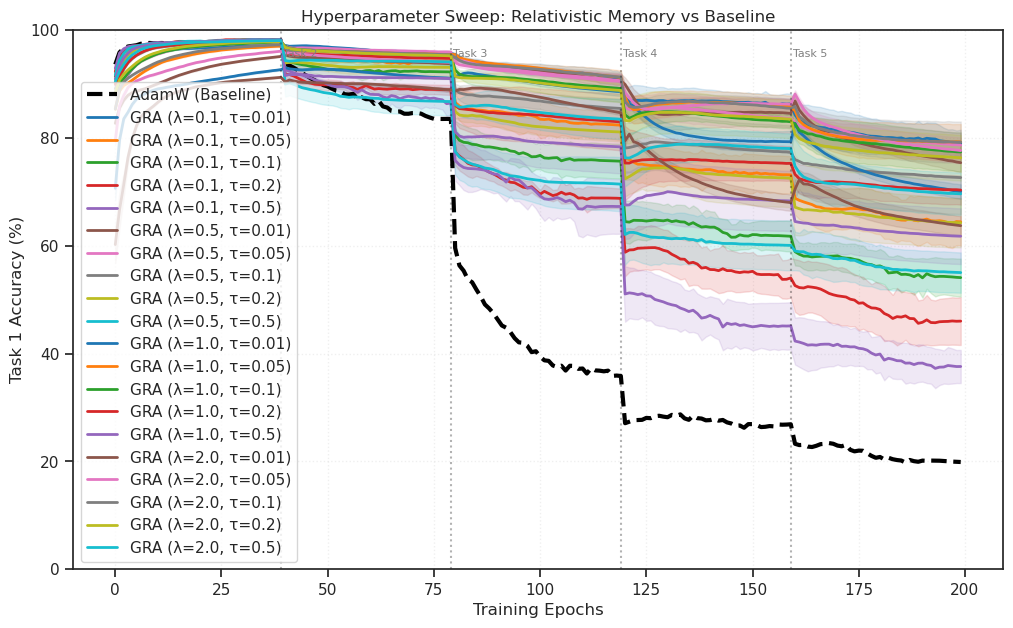

In [164]:
plot_sweep_results(sweep_data)

In [192]:
class ReservoirBuffer:
    def __init__(self, buffer_size=2000, input_shape=(784,)):
        self.max_size = buffer_size
        self.current_size = 0
        self.seen_so_far = 0  # Counter for all data seen
        self.x_data = torch.zeros((buffer_size, *input_shape))
        self.y_data = torch.zeros(buffer_size, dtype=torch.long)
        
    def add(self, x, y):
        """
        Adds data using Reservoir Sampling logic.
        This ensures the buffer remains a uniform sample of ALL history.
        """
        batch_size = x.size(0)
        
        # 1. First, fill the buffer if there is space
        if self.current_size < self.max_size:
            space = self.max_size - self.current_size
            take = min(space, batch_size)
            
            # Fill
            self.x_data[self.current_size : self.current_size+take] = x[:take].cpu()
            self.y_data[self.current_size : self.current_size+take] = y[:take].cpu()
            self.current_size += take
            self.seen_so_far += take
            
            # If we processed the whole batch, return
            if take == batch_size:
                return
            
            # If there is leftover data, fall through to replacement logic
            x = x[take:]
            y = y[take:]
            batch_size = x.size(0)

        # 2. Reservoir Replacement
        indices = torch.randint(0, self.max_size, (batch_size,))
        self.x_data[indices] = x.cpu()
        self.y_data[indices] = y.cpu()
        
        self.seen_so_far += batch_size

    def sample(self, batch_size):
        if self.current_size == 0:
            return None, None
        
        indices = np.random.choice(self.current_size, min(batch_size, self.current_size), replace=False)
        x = self.x_data[indices].to(device)
        y = self.y_data[indices].to(device)
        return x, y

In [209]:
def run_experience_replay(config, trn_loader, vld_loader, n_tasks=5, buffer_size=5000, replay_ratio=0.8):
    """
    Runs Experience Replay with a strict 'Fixed Batch Size' composition.
    
    Args:
        replay_ratio (float): Fraction of the batch to fill with Replay data. 
                              e.g., 0.8 means 80% Replay, 20% Stream.
    """
    # Setup
    seed = config['seed']
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = MLP(hidden_size=256).to(device)
    base_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    if config['use_gra']:
        optimizer = RelativisticMemoryOptimizer(
            base_opt, 
            coupling_strength=config['lambda'], 
            memory_timescale=config['tau']
        )
    else:
        optimizer = base_opt

    criterion = nn.CrossEntropyLoss()
    perms = get_permutations(n_tasks, seed=42)
    
    # Use the Reservoir Buffer
    buffer = ReservoirBuffer(buffer_size=buffer_size)
    
    history = []
    
    for task_idx in range(n_tasks):
        current_perm = perms[task_idx]
        
        for epoch in range(config['epochs']):
            model.train()
            
            for x, y in trn_loader:
                # 1. Prepare Data
                x, y = x.to(device), y.to(device).long()
                
                batch_size = x.size(0)
                
                # 2. Determine Split (Target Counts)
                n_replay_target = int(batch_size * replay_ratio)
                
                # 3. Fetch Replay Data
                # Note: Might return fewer than n_replay_target if buffer is empty/small
                x_replay, y_replay = buffer.sample(n_replay_target)
                
                n_replay_actual = 0
                if x_replay is not None:
                    n_replay_actual = x_replay.size(0)
                
                # 4. Determine Stream Data Needed
                # We fill the remainder of the batch with stream data to ensure stability
                n_stream_needed = batch_size - n_replay_actual
                
                # 5. Sample Stream Indices (Without Replacement)
                if n_stream_needed < batch_size:
                    # Randomly pick subset of indices
                    indices = torch.randperm(batch_size)[:n_stream_needed]
                    x_stream_subset = x[indices]
                    y_stream_subset = y[indices]
                else:
                    # Take whole batch if buffer provided nothing
                    x_stream_subset = x
                    y_stream_subset = y
                
                # Apply permutation to the stream subset
                x_stream_subset = apply_perm(x_stream_subset, current_perm)
                
                # 6. Concatenate
                if n_replay_actual > 0:
                    x_combined = torch.cat([x_stream_subset, x_replay], dim=0)
                    y_combined = torch.cat([y_stream_subset, y_replay], dim=0)
                else:
                    x_combined = x_stream_subset
                    y_combined = y_stream_subset
                
                # 7. Optimization Step
                optimizer.zero_grad()
                loss = criterion(model(x_combined), y_combined)
                loss.backward()
                optimizer.step()
                
                # 8. Update Buffer
                # We add the FULL stream batch to the reservoir to ensure good coverage
                # (permuted, so the buffer holds the transformed 'task specific' view)
                x_full_perm = apply_perm(x, current_perm)
                buffer.add(x_full_perm.detach(), y.detach())

            # Metric: Task 1 Retention
            model.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for x, y in vld_loader:
                    x, y = x.to(device), y.to(device)
                    x = apply_perm(x, perms[0])
                    pred = model(x).argmax(1)
                    correct += (pred == y).sum().item()
                    total += y.size(0)
            
            history.append(100.0 * correct / total)
            
    return np.array(history)

In [216]:
shared_kws = dict(seed=42, epochs=40)

configs = [
    {'label': 'ER (Strong Baseline)', 'use_gra': False, **shared_kws},
    {'label': 'ER + GRA (Augmented)', 'use_gra': True, 'lambda': 0.1, 'tau': 0.01, **shared_kws}
]

In [217]:
expt_kws = dict(
    n_tasks=10,
    buffer_size=5000,
    replay_ratio=0.5,
)

results_sota = {}

for conf in configs:
    print(f"--> {conf['label']}")
    results_sota[conf['label']] = run_experience_replay(
        conf, trn_loader, vld_loader, **expt_kws)

--> ER (Strong Baseline)

--> ER + GRA (Augmented)

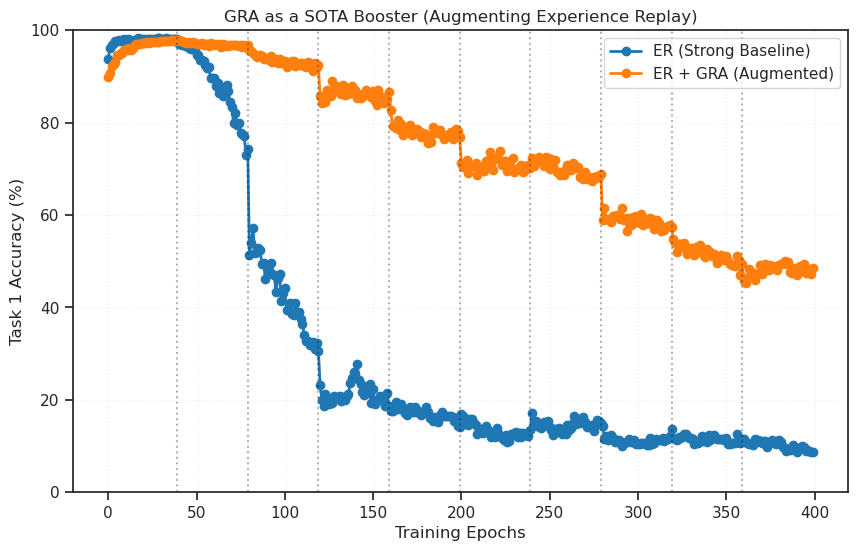

Final Accuracy Comparison:

ER Only:      8.62%

ER + GRA:     48.45%

Improvement:  +39.83%

In [219]:
plt.figure(figsize=(10, 6))
for label, res in results_sota.items():
    plt.plot(res, '-o', label=label, linewidth=2)

total_epochs = len(next(iter(results_sota.values())))
epochs_per_task = total_epochs // expt_kws['n_tasks']
for i in range(1, expt_kws['n_tasks']):
    boundary = i * epochs_per_task - 1
    plt.axvline(boundary, color='k', linestyle=':', alpha=0.3)

plt.title("GRA as a SOTA Booster (Augmenting Experience Replay)")
plt.xlabel("Training Epochs")
plt.ylabel("Task 1 Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.show()

# Print Final Delta
base_acc = results_sota['ER (Strong Baseline)'][-1]
aug_acc = results_sota['ER + GRA (Augmented)'][-1]
print(f"\nFinal Accuracy Comparison:")
print(f"ER Only:      {base_acc:.2f}%")
print(f"ER + GRA:     {aug_acc:.2f}%")
print(f"Improvement:  {aug_acc - base_acc:+.2f}%")

In [227]:
shared_kws = dict(seed=42, epochs=40)

configs = [
    {'label': 'ER (Strong Baseline)', 'use_gra': False, **shared_kws},
    {'label': 'ER + GRA (Augmented)', 'use_gra': True, 'lambda': 0.1, 'tau': 0.01, **shared_kws}
]

In [228]:
expt_kws = dict(
    n_tasks=10,
    buffer_size=5000,
    replay_ratio=0.8,
)

results_sota = {}

for conf in configs:
    print(f"--> {conf['label']}")
    results_sota[conf['label']] = run_experience_replay(
        conf, trn_loader, vld_loader, **expt_kws)

--> ER (Strong Baseline)

--> ER + GRA (Augmented)

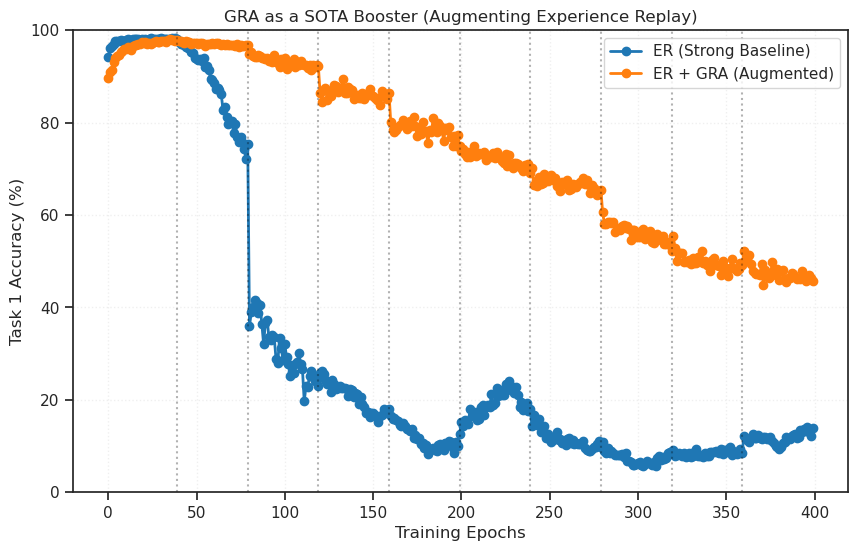

Final Accuracy Comparison:

ER Only:      13.80%

ER + GRA:     45.67%

Improvement:  +31.87%

In [229]:
plt.figure(figsize=(10, 6))
for label, res in results_sota.items():
    plt.plot(res, '-o', label=label, linewidth=2)

total_epochs = len(next(iter(results_sota.values())))
epochs_per_task = total_epochs // expt_kws['n_tasks']
for i in range(1, expt_kws['n_tasks']):
    boundary = i * epochs_per_task - 1
    plt.axvline(boundary, color='k', linestyle=':', alpha=0.3)

plt.title("GRA as a SOTA Booster (Augmenting Experience Replay)")
plt.xlabel("Training Epochs")
plt.ylabel("Task 1 Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.show()

# Print Final Delta
base_acc = results_sota['ER (Strong Baseline)'][-1]
aug_acc = results_sota['ER + GRA (Augmented)'][-1]
print(f"\nFinal Accuracy Comparison:")
print(f"ER Only:      {base_acc:.2f}%")
print(f"ER + GRA:     {aug_acc:.2f}%")
print(f"Improvement:  {aug_acc - base_acc:+.2f}%")

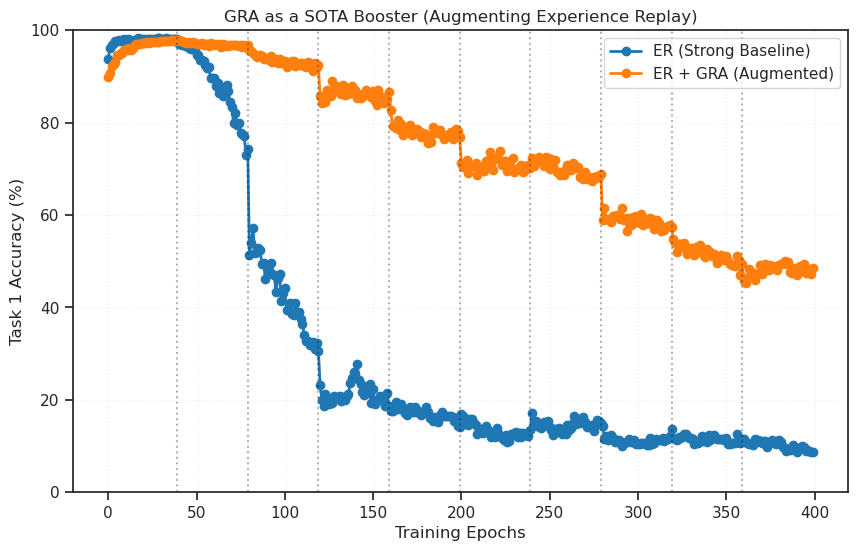

Final Accuracy Comparison:

ER Only:      8.62%

ER + GRA:     48.45%

Improvement:  +39.83%